<a href="https://colab.research.google.com/github/dohaalnabahin/chicago-crime-time-series-analysis/blob/main/Project3_Part2_Chicago_Crime.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Project 3 - Part 1: Chicago Crime Time Series Analysis**

# Business Understanding

This project analyzes reported crime incidents in Chicago to understand how crime patterns change across time, locations, and specific calendar events. The main stakeholder is a local newspaper reporter who wants clear, data-supported insights about crime trends in the city.

Unlike a classical machine learning workflow, the goal of this project is not to build a predictive model or classify future crimes. Instead, this project focuses on **time series analysis**, where the main objective is to explore how crime changes over time and answer real stakeholder questions using trends, comparisons, and visualizations.

The dataset contains individual crime reports, where each row represents one crime incident with information such as the crime type, date and time, district, arrest status, and location details. To answer the questions, the data will be prepared in two useful formats:

* **Original crime-level data:** each row represents one crime.
* **Resampled time series data:** crimes are aggregated by day, month, year, or other time periods.

For this analysis, I selected four main topics:

1. **Comparing Police Districts**
   To identify which police districts had the highest and lowest number of crimes.

2. **Crimes Across the Years**
   To understand whether total crime is increasing or decreasing over time and whether specific crime types follow different trends.

3. **AM vs PM Rush Hour**
   To compare crime patterns during morning and evening rush hours and identify the most common crimes in each period.

4. **Comparing Holidays**
   To investigate whether certain holidays have higher crime counts and determine the most common crimes during those holidays.

The final goal is to turn raw crime data into clear insights that can help explain when, where, and what types of crimes are most common in Chicago.


#**Loading and Inspecting the Data**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import glob
import os

folder = "/content/drive/MyDrive/AXSOSACADEMY/05-IntermediateML/data"

files = sorted(glob.glob(folder + "/*.csv"))

len(files), files[:3], files[-3:]

(22,
 ['/content/drive/MyDrive/AXSOSACADEMY/05-IntermediateML/data/Chicago-Crime_2001.csv',
  '/content/drive/MyDrive/AXSOSACADEMY/05-IntermediateML/data/Chicago-Crime_2002.csv',
  '/content/drive/MyDrive/AXSOSACADEMY/05-IntermediateML/data/Chicago-Crime_2003.csv'],
 ['/content/drive/MyDrive/AXSOSACADEMY/05-IntermediateML/data/Chicago-Crime_2020.csv',
  '/content/drive/MyDrive/AXSOSACADEMY/05-IntermediateML/data/Chicago-Crime_2021.csv',
  '/content/drive/MyDrive/AXSOSACADEMY/05-IntermediateML/data/Chicago-Crime_2022.csv'])

In [ ]:
import pandas as pd

dfs = []

for file in files:
    temp = pd.read_csv(file, low_memory=False)
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

df.head()

,ID,Date,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude
0,1326041,01/01/2001 01:00:00 AM,BATTERY,SIMPLE,RESIDENCE,False,False,1624,16.0,NaN,41.957850,-87.749185
1,1319931,01/01/2001 01:00:00 PM,BATTERY,SIMPLE,RESIDENCE,False,True,825,8.0,NaN,41.783892,-87.684841
2,1324743,01/01/2001 01:00:00 PM,GAMBLING,ILLEGAL ILL LOTTERY,STREET,True,False,313,3.0,NaN,41.780412,-87.611970
3,1310717,01/01/2001 01:00:00 AM,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,2424,24.0,NaN,42.012391,-87.678032
4,1318099,01/01/2001 01:00:00 AM,BATTERY,SIMPLE,RESIDENCE PORCH/HALLWAY,False,True,214,2.0,NaN,41.819538,-87.620020


#**Data Preparation**

To prepare the dataset for time series analysis, the original `Date` column was converted into a real datetime format and set as the index. This is important because time series analysis depends on time-based filtering, resampling, and feature extraction.

After setting the datetime index, new time-based features were created, such as year, month, hour, and day of week. These features will help answer stakeholder questions about crime trends across years, rush hours, months, holidays, and police districts.


In [ ]:
# Convert Date column to datetime
df["Datetime"] = pd.to_datetime(df["Date"], errors="coerce")

# Drop rows with invalid dates
df = df.dropna(subset=["Datetime"]).copy()

# Set Datetime as the index
df = df.set_index("Datetime").sort_index()

# Drop original Date column because Datetime index will be used
df = df.drop(columns=["Date"])

# Create time-based features
df["Year"] = df.index.year
df["Month"] = df.index.month
df["MonthName"] = df.index.month_name()
df["Hour"] = df.index.hour
df["DayOfWeek"] = df.index.day_name()

df.head()

,ID,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude,Year,Month,MonthName,Hour,DayOfWeek
Datetime,,,,,,,,,,,,,,,,
2001-01-01,3214584,THEFT,FINANCIAL ID THEFT: OVER $300,STREET,False,False,2221,22.0,21.0,41.732563,-87.669923,2001,1,January,0,Monday
2001-01-01,1927872,THEFT,AGG: FINANCIAL ID THEFT,RESIDENCE,False,False,812,8.0,NaN,41.778094,-87.770137,2001,1,January,0,Monday
2001-01-01,4768442,OFFENSE INVOLVING CHILDREN,SEX ASSLT OF CHILD BY FAM MBR,RESIDENCE,False,False,2124,2.0,4.0,41.807275,-87.593707,2001,1,January,0,Monday
2001-01-01,2280620,THEFT,FINANCIAL ID THEFT: OVER $300,RESIDENCE,False,False,915,9.0,20.0,41.806311,-87.674782,2001,1,January,0,Monday
2001-01-01,9755214,SEX OFFENSE,AGG CRIMINAL SEXUAL ABUSE,CHURCH/SYNAGOGUE/PLACE OF WORSHIP,False,False,1022,10.0,24.0,NaN,NaN,2001,1,January,0,Monday


#**Topic 1: Comparing Police Districts**

##Which district had the most crimes in 2022?

##Which had the least?

In [ ]:
# Filter data for 2022 only
df_2022 = df.loc["2022"].copy()

df_2022.head()

,ID,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude,Year,Month,MonthName,Hour,DayOfWeek
Datetime,,,,,,,,,,,,,,,,
2022-01-01,12701677,OTHER OFFENSE,HARASSMENT BY TELEPHONE,RESIDENCE,False,True,2413,24.0,40.0,41.994004,-87.697387,2022,1,January,0,Saturday
2022-01-01,12615410,DECEPTIVE PRACTICE,"THEFT BY LESSEE, MOTOR VEHICLE",STREET,False,False,1235,12.0,25.0,41.852750,-87.640816,2022,1,January,0,Saturday
2022-01-01,12658052,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,APARTMENT,False,False,511,5.0,8.0,41.717813,-87.598279,2022,1,January,0,Saturday
2022-01-01,12957426,OFFENSE INVOLVING CHILDREN,SEXUAL ASSAULT OF CHILD BY FAMILY MEMBER,RESIDENCE,False,True,632,6.0,8.0,NaN,NaN,2022,1,January,0,Saturday
2022-01-01,13002739,OFFENSE INVOLVING CHILDREN,CRIMINAL SEXUAL ABUSE BY FAMILY MEMBER,APARTMENT,False,True,734,7.0,17.0,NaN,NaN,2022,1,January,0,Saturday


##We count crimes by district

In [ ]:
district_2022_counts = (
    df_2022
    .dropna(subset=["District"])
    .groupby("District")
    .size()
    .sort_values(ascending=False)
)

district_2022_counts

,0
District,
8.0,14805
6.0,14694
12.0,14341
4.0,13931
11.0,13457
1.0,13044
18.0,12429
19.0,12243
25.0,11951


##More District and Less District:

In [ ]:
most_crime_district = district_2022_counts.idxmax()
most_crime_count = district_2022_counts.max()

least_crime_district = district_2022_counts.idxmin()
least_crime_count = district_2022_counts.min()

print(f"District with the most crimes in 2022: {most_crime_district}")
print(f"Number of crimes: {most_crime_count}")

print(f"District with the least crimes in 2022: {least_crime_district}")
print(f"Number of crimes: {least_crime_count}")

District with the most crimes in 2022: 8.0
Number of crimes: 14805
District with the least crimes in 2022: 31.0
Number of crimes: 15


##Visualization

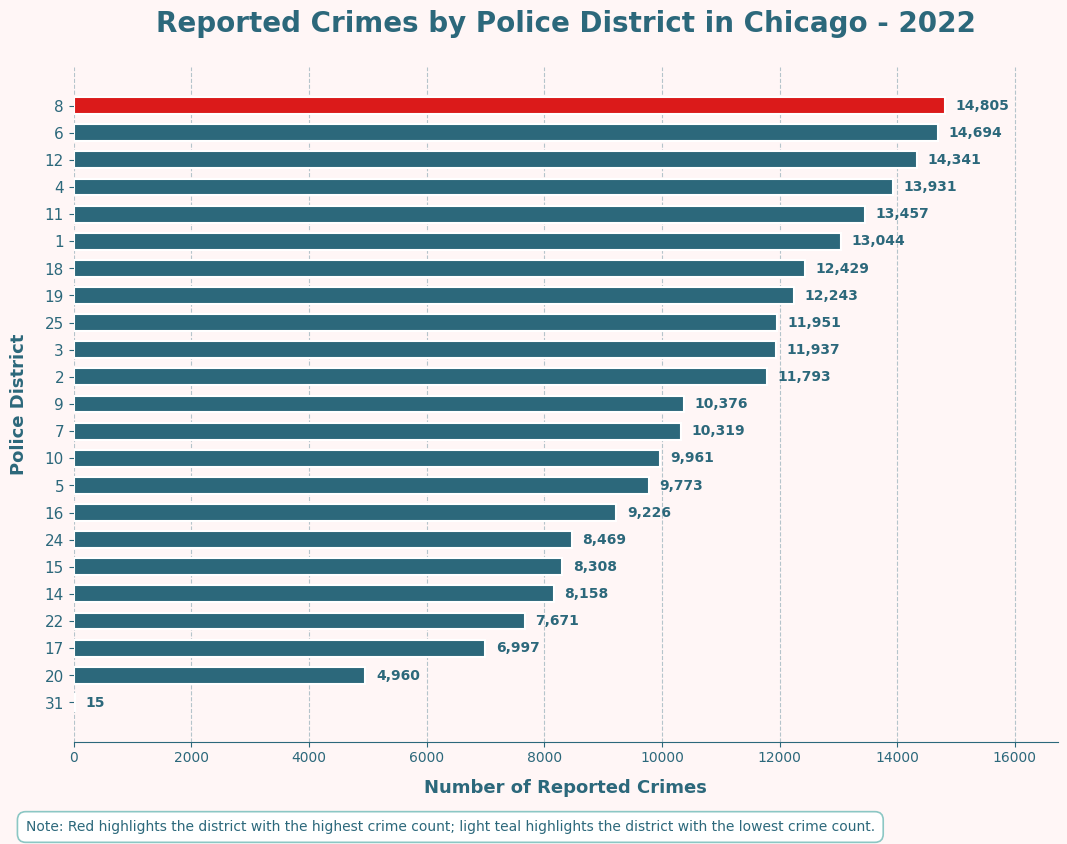

In [ ]:
# Professional chart style colors
RED = "#DB1A1A"
BG = "#FFF6F6"
TEAL = "#8CC7C4"
DARK_TEAL = "#2C687B"

# Sort districts from lowest to highest for horizontal bar chart
plot_data = district_2022_counts.sort_values()

# Highlight highest and lowest districts
bar_colors = []
for district in plot_data.index:
    if district == district_2022_counts.idxmax():
        bar_colors.append(RED)
    elif district == district_2022_counts.idxmin():
        bar_colors.append(TEAL)
    else:
        bar_colors.append(DARK_TEAL)

fig, ax = plt.subplots(figsize=(12, 9), facecolor=BG)
ax.set_facecolor(BG)

bars = ax.barh(
    plot_data.index.astype(int).astype(str),
    plot_data.values,
    color=bar_colors,
    edgecolor="white",
    linewidth=1.5,
    height=0.62
)

# Add value labels
max_value = plot_data.max()

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + max_value * 0.012,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width):,}",
        va="center",
        fontsize=10,
        color=DARK_TEAL,
        fontweight="bold"
    )

# Titles and labels
ax.set_title(
    "Reported Crimes by Police District in Chicago - 2022",
    fontsize=20,
    fontweight="bold",
    color=DARK_TEAL,
    pad=25
)

ax.set_xlabel(
    "Number of Reported Crimes",
    fontsize=13,
    color=DARK_TEAL,
    fontweight="bold",
    labelpad=10
)

ax.set_ylabel(
    "Police District",
    fontsize=13,
    color=DARK_TEAL,
    fontweight="bold",
    labelpad=12
)

# Grid styling
ax.grid(axis="x", linestyle="--", alpha=0.35, color=DARK_TEAL)
ax.set_axisbelow(True)

# Remove unnecessary borders
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

ax.spines["bottom"].set_color(DARK_TEAL)

ax.tick_params(axis="x", colors=DARK_TEAL, labelsize=10)
ax.tick_params(axis="y", colors=DARK_TEAL, labelsize=11)

# Give extra space on the right for labels
ax.set_xlim(0, max_value * 1.13)

# Add clean note below chart with padding
note_text = (
    "Note: Red highlights the district with the highest crime count; "
    "light teal highlights the district with the lowest crime count."
)

fig.text(
    0.08, 0.035,
    note_text,
    ha="left",
    va="center",
    fontsize=10,
    color=DARK_TEAL,
    bbox=dict(
        facecolor="white",
        edgecolor=TEAL,
        boxstyle="round,pad=0.6",
        linewidth=1.2
    )
)

# Adjust layout to leave space for note
plt.subplots_adjust(left=0.12, right=0.94, top=0.88, bottom=0.13)

plt.show()

# Topic 1: Comparing Police Districts

### 1. Methodology
This analysis compares the number of reported crimes across Chicago police districts during 2022.
* **Data Filtering:** Includes only crimes reported in the year 2022.
* **Data Grouping:** Metrics are aggregated by individual police district.

---

### 2. Key Findings
* **Highest Crime Count:** District 8, with a total of **14,805 reported crimes**.
* **Lowest Crime Count:** District 31, with a total of **15 reported crimes**.

---

### 3. Analysis & Observations
The visualization indicates that crime distribution is not uniform across police districts:
* High-density crime counts are concentrated in specific areas, notably **District 8**, **District 6**, and **District 12**.
* Conversely, several other districts exhibit significantly lower reporting volumes.

### 4. Contributing Factors
The observed variance in crime distribution may be attributed to:
* Population density and demographics
* District-specific commercial and social activity
* Variations in public reporting patterns
* Geographic and administrative district boundaries


#**Topic 2: Crimes Across the Years**

##Is the total number of crimes increasing or decreasing across the years?

##Are there any individual crimes that are doing the opposite (e.g., decreasing when overall crime is increasing or vice-versa)?

##Total crimes by year

In [ ]:
# Count total crimes per year
annual_total = df.resample("YE").size()

# Convert datetime year-end index to year numbers
annual_total.index = annual_total.index.year

annual_total

,0
Datetime,
2001,485886
2002,486807
2003,475985
2004,469422
2005,453773
2006,448179
2007,437087
2008,427183
2009,392827


##Visualization

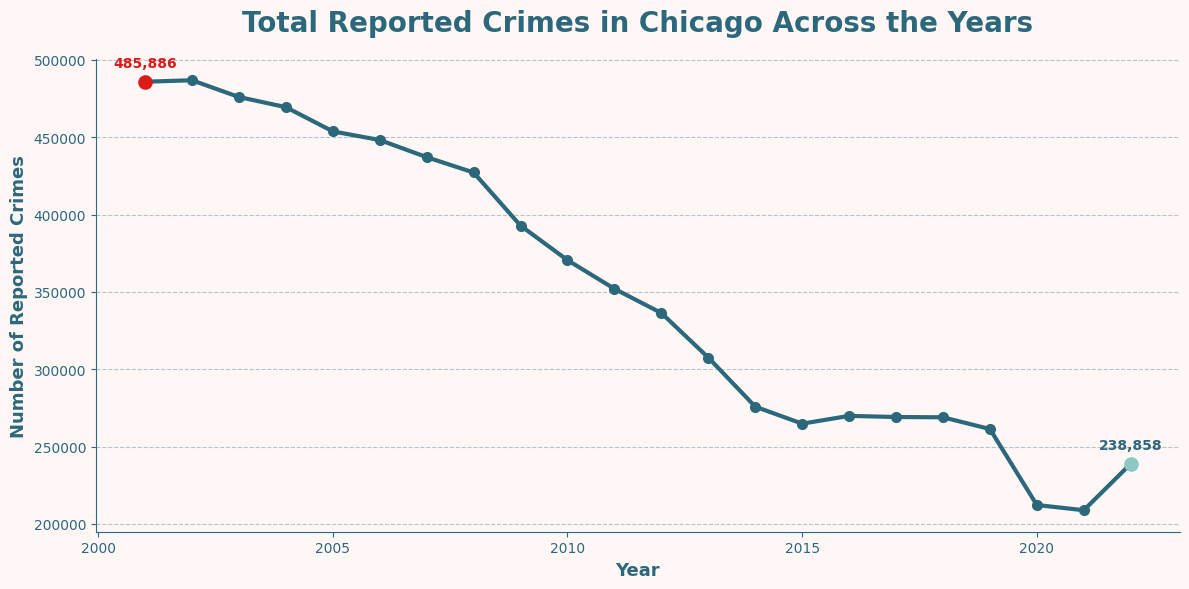

In [ ]:
RED = "#DB1A1A"
BG = "#FFF6F6"
TEAL = "#8CC7C4"
DARK_TEAL = "#2C687B"

fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG)
ax.set_facecolor(BG)

ax.plot(
    annual_total.index,
    annual_total.values,
    marker="o",
    linewidth=3,
    markersize=7,
    color=DARK_TEAL
)

# Highlight first and last year
ax.scatter(annual_total.index[0], annual_total.iloc[0], color=RED, s=90, zorder=5)
ax.scatter(annual_total.index[-1], annual_total.iloc[-1], color=TEAL, s=90, zorder=5)

# Add value labels for first and last year
ax.text(
    annual_total.index[0],
    annual_total.iloc[0] + annual_total.max()*0.02,
    f"{annual_total.iloc[0]:,}",
    ha="center",
    color=RED,
    fontweight="bold"
)

ax.text(
    annual_total.index[-1],
    annual_total.iloc[-1] + annual_total.max()*0.02,
    f"{annual_total.iloc[-1]:,}",
    ha="center",
    color=DARK_TEAL,
    fontweight="bold"
)

ax.set_title(
    "Total Reported Crimes in Chicago Across the Years",
    fontsize=20,
    fontweight="bold",
    color=DARK_TEAL,
    pad=20
)

ax.set_xlabel("Year", fontsize=13, color=DARK_TEAL, fontweight="bold")
ax.set_ylabel("Number of Reported Crimes", fontsize=13, color=DARK_TEAL, fontweight="bold")

ax.grid(axis="y", linestyle="--", alpha=0.35, color=DARK_TEAL)
ax.set_axisbelow(True)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["bottom"].set_color(DARK_TEAL)
ax.spines["left"].set_color(DARK_TEAL)

ax.tick_params(axis="x", colors=DARK_TEAL)
ax.tick_params(axis="y", colors=DARK_TEAL)

plt.tight_layout()
plt.show()

##We calculate whether the general trend has increased or decreased.

In [ ]:
first_year = annual_total.index.min()
last_year = annual_total.index.max()

first_year_count = annual_total.loc[first_year]
last_year_count = annual_total.loc[last_year]

overall_change = last_year_count - first_year_count
overall_pct_change = (overall_change / first_year_count) * 100

print(f"First year: {first_year} = {first_year_count:,} crimes")
print(f"Last year: {last_year} = {last_year_count:,} crimes")
print(f"Overall change: {overall_change:,} crimes")
print(f"Percent change: {overall_pct_change:.2f}%")

if overall_change > 0:
    print("Overall trend: Increasing")
else:
    print("Overall trend: Decreasing")

First year: 2001 = 485,886 crimes
Last year: 2022 = 238,858 crimes
Overall change: -247,028 crimes
Percent change: -50.84%
Overall trend: Decreasing


##Types of crimes: Which increased and which decreased?

In [ ]:
crime_by_year = (
    df.groupby("Primary Type")
    .resample("YE")
    .size()
    .reset_index(name="Crime Count")
)

crime_by_year["Year"] = crime_by_year["Datetime"].dt.year

crime_year_pivot = crime_by_year.pivot(
    index="Year",
    columns="Primary Type",
    values="Crime Count"
).fillna(0)

crime_year_pivot.head()

Primary Type,ARSON,ASSAULT,BATTERY,BURGLARY,CONCEALED CARRY LICENSE VIOLATION,CRIM SEXUAL ASSAULT,CRIMINAL DAMAGE,CRIMINAL SEXUAL ASSAULT,CRIMINAL TRESPASS,DECEPTIVE PRACTICE,DOMESTIC VIOLENCE,GAMBLING,HOMICIDE,HUMAN TRAFFICKING,INTERFERENCE WITH PUBLIC OFFICER,INTIMIDATION,KIDNAPPING,LIQUOR LAW VIOLATION,MOTOR VEHICLE THEFT,NARCOTICS,NON - CRIMINAL,NON-CRIMINAL,NON-CRIMINAL (SUBJECT SPECIFIED),OBSCENITY,OFFENSE INVOLVING CHILDREN,OTHER NARCOTIC VIOLATION,OTHER OFFENSE,PROSTITUTION,PUBLIC INDECENCY,PUBLIC PEACE VIOLATION,RITUALISM,ROBBERY,SEX OFFENSE,STALKING,THEFT,WEAPONS VIOLATION
Year,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2001,1011.0,31384.0,93461.0,26014.0,1.0,1779.0,55859.0,29.0,13241.0,14949.0,1.0,934.0,667.0,0.0,406.0,279.0,933.0,1637.0,27553.0,50567.0,0.0,0.0,0.0,19.0,2263.0,6.0,29662.0,6026.0,9.0,2750.0,8.0,18441.0,2239.0,204.0,99277.0,4277.0
2002,1032.0,31523.0,94153.0,25623.0,0.0,1807.0,55941.0,27.0,13880.0,13732.0,0.0,971.0,658.0,0.0,361.0,337.0,829.0,1414.0,25121.0,51789.0,0.0,0.0,0.0,26.0,2594.0,5.0,32600.0,6408.0,8.0,2457.0,2.0,18523.0,2173.0,200.0,98332.0,4281.0
2003,955.0,29477.0,88380.0,25157.0,0.0,1571.0,55011.0,41.0,14807.0,13459.0,0.0,1088.0,604.0,0.0,409.0,364.0,705.0,1311.0,22748.0,54288.0,0.0,1.0,0.0,16.0,3047.0,2.0,31148.0,6214.0,6.0,2430.0,2.0,17332.0,2078.0,247.0,98876.0,4211.0
2004,778.0,28850.0,87136.0,24564.0,0.0,1538.0,53164.0,42.0,15913.0,13255.0,0.0,1122.0,455.0,0.0,531.0,349.0,482.0,985.0,22805.0,57060.0,0.0,0.0,0.0,13.0,3099.0,9.0,29532.0,7476.0,9.0,2495.0,1.0,15978.0,1805.0,215.0,95463.0,4298.0
2005,691.0,27067.0,83964.0,25503.0,0.0,1521.0,54548.0,37.0,16655.0,13590.0,0.0,1078.0,453.0,0.0,615.0,258.0,389.0,1005.0,22497.0,56234.0,0.0,0.0,0.0,19.0,2906.0,9.0,28028.0,6124.0,4.0,2730.0,2.0,16047.0,1817.0,192.0,85684.0,4106.0


##Calculating the change for each type of crime

In [ ]:
crime_change = pd.DataFrame({
    "First Year Count": crime_year_pivot.loc[first_year],
    "Last Year Count": crime_year_pivot.loc[last_year]
})

crime_change["Change"] = crime_change["Last Year Count"] - crime_change["First Year Count"]

crime_change["Percent Change"] = np.where(
    crime_change["First Year Count"] > 0,
    (crime_change["Change"] / crime_change["First Year Count"]) * 100,
    np.nan
)

crime_change = crime_change.sort_values("Change", ascending=False)

crime_change

,First Year Count,Last Year Count,Change,Percent Change
Primary Type,,,,
WEAPONS VIOLATION,4277.0,8766.0,4489.0,104.956745
CRIMINAL SEXUAL ASSAULT,29.0,1559.0,1530.0,5275.862069
DECEPTIVE PRACTICE,14949.0,16405.0,1456.0,9.739782
STALKING,204.0,446.0,242.0,118.627451
CONCEALED CARRY LICENSE VIOLATION,1.0,177.0,176.0,17600.000000
HOMICIDE,667.0,725.0,58.0,8.695652
OBSCENITY,19.0,49.0,30.0,157.894737
HUMAN TRAFFICKING,0.0,17.0,17.0,NaN
NON-CRIMINAL,0.0,5.0,5.0,NaN


##Crimes that go against the general trend

In [ ]:
if overall_change < 0:
    opposite_crimes = crime_change[crime_change["Change"] > 0].sort_values("Change", ascending=False)
else:
    opposite_crimes = crime_change[crime_change["Change"] < 0].sort_values("Change")

opposite_crimes

,First Year Count,Last Year Count,Change,Percent Change
Primary Type,,,,
WEAPONS VIOLATION,4277.0,8766.0,4489.0,104.956745
CRIMINAL SEXUAL ASSAULT,29.0,1559.0,1530.0,5275.862069
DECEPTIVE PRACTICE,14949.0,16405.0,1456.0,9.739782
STALKING,204.0,446.0,242.0,118.627451
CONCEALED CARRY LICENSE VIOLATION,1.0,177.0,176.0,17600.000000
HOMICIDE,667.0,725.0,58.0,8.695652
OBSCENITY,19.0,49.0,30.0,157.894737
HUMAN TRAFFICKING,0.0,17.0,17.0,NaN
NON-CRIMINAL,0.0,5.0,5.0,NaN


##Visualization

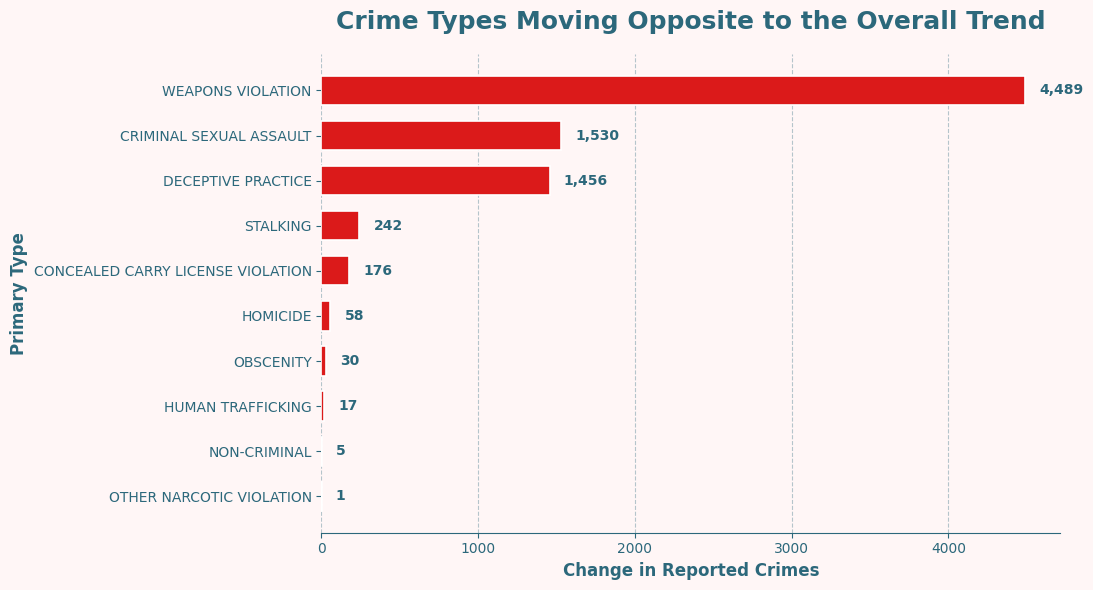

In [ ]:
plot_opposite = opposite_crimes.head(10).sort_values("Change")

fig, ax = plt.subplots(figsize=(11, 6), facecolor=BG)
ax.set_facecolor(BG)

ax.barh(
    plot_opposite.index,
    plot_opposite["Change"],
    color=RED,
    edgecolor="white",
    linewidth=1.2,
    height=0.65
)

for i, value in enumerate(plot_opposite["Change"]):
    ax.text(
        value + (plot_opposite["Change"].max() * 0.02),
        i,
        f"{int(value):,}",
        va="center",
        fontsize=10,
        color=DARK_TEAL,
        fontweight="bold"
    )

ax.set_title(
    "Crime Types Moving Opposite to the Overall Trend",
    fontsize=18,
    fontweight="bold",
    color=DARK_TEAL,
    pad=18
)

ax.set_xlabel("Change in Reported Crimes", fontsize=12, color=DARK_TEAL, fontweight="bold")
ax.set_ylabel("Primary Type", fontsize=12, color=DARK_TEAL, fontweight="bold")

ax.grid(axis="x", linestyle="--", alpha=0.35, color=DARK_TEAL)
ax.set_axisbelow(True)

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

ax.spines["bottom"].set_color(DARK_TEAL)
ax.tick_params(axis="x", colors=DARK_TEAL)
ax.tick_params(axis="y", colors=DARK_TEAL)

plt.tight_layout()
plt.show()

In [ ]:
annual_total

,0
Datetime,
2001,485886
2002,486807
2003,475985
2004,469422
2005,453773
2006,448179
2007,437087
2008,427183
2009,392827


In [ ]:
opposite_crimes.head(10)

,First Year Count,Last Year Count,Change,Percent Change
Primary Type,,,,
WEAPONS VIOLATION,4277.0,8766.0,4489.0,104.956745
CRIMINAL SEXUAL ASSAULT,29.0,1559.0,1530.0,5275.862069
DECEPTIVE PRACTICE,14949.0,16405.0,1456.0,9.739782
STALKING,204.0,446.0,242.0,118.627451
CONCEALED CARRY LICENSE VIOLATION,1.0,177.0,176.0,17600.000000
HOMICIDE,667.0,725.0,58.0,8.695652
OBSCENITY,19.0,49.0,30.0,157.894737
HUMAN TRAFFICKING,0.0,17.0,17.0,NaN
NON-CRIMINAL,0.0,5.0,5.0,NaN


# Topic 2: Crimes Across the Years

### 1. Methodology
This analysis examines the temporal trajectory of reported crimes in Chicago from 2001 to 2022.
* **Data Aggregation:** The dataset was grouped by year to compute the annual aggregate of reported offenses.
* **Objective:** To determine the long-term macro trends in criminal activity over a 21-year period.

---

### 2. Macro Trend Analysis (2001 vs. 2022)
The empirical data indicates a substantial downward trend in overall reported crimes:
* **Volume in 2001:** 485,886 reported crimes.
* **Volume in 2022:** 238,858 reported crimes.
* **Net Reduction:** **247,028 offenses** (a percentage decrease of approximately **50.84%**).

---

### 3. Micro Trends: Increasing Crime Categories
While the aggregate crime rate decreased, specific offense categories experienced divergent upward trends. The most significant net increases include:

* **Weapons Violation:** +4,489 crimes
* **Criminal Sexual Assault:** +1,530 crimes
* **Deceptive Practice:** +1,456 crimes
* **Stalking:** +242 crimes
* **Concealed Carry License Violation:** +176 crimes
* **Homicide:** +58 crimes

---

### 4. Critical Analytical Insights
* **Divergent Patterns:** Aggregate declines do not imply uniform reductions across all crime types; specific offenses may fluctuate due to shifts in criminal behavior, law enforcement focus, or societal changes.


#**Topic 3: AM vs PM Rush Hour**

##Are crimes more common during AM rush hour or PM rush hour?


##What are the top 5 most common crimes during AM rush hour? What are the top 5 most common crimes during PM rush hour?


##Are Motor Vehicle Thefts more common during AM rush hour or PM Rush Hour?

##Creating a Rush Hour Column

In [ ]:
# Make sure Hour column exists
df["Hour"] = df.index.hour

# Create Rush Hour column
df["Rush Hour"] = "Other"

df.loc[(df["Hour"] >= 7) & (df["Hour"] < 10), "Rush Hour"] = "AM Rush Hour"
df.loc[(df["Hour"] >= 16) & (df["Hour"] < 19), "Rush Hour"] = "PM Rush Hour"

# Keep only rush hour crimes
rush_df = df[df["Rush Hour"].isin(["AM Rush Hour", "PM Rush Hour"])].copy()

rush_df[["Primary Type", "Hour", "Rush Hour"]].head()

,Primary Type,Hour,Rush Hour
Datetime,,,
2001-01-01 07:00:00,THEFT,7,AM Rush Hour
2001-01-01 07:00:00,THEFT,7,AM Rush Hour
2001-01-01 07:00:00,MOTOR VEHICLE THEFT,7,AM Rush Hour
2001-01-01 07:00:00,BATTERY,7,AM Rush Hour
2001-01-01 07:00:00,BURGLARY,7,AM Rush Hour


##Are crimes more common in AM or PM?

In [ ]:
rush_counts = rush_df["Rush Hour"].value_counts()

rush_counts

,count
Rush Hour,
PM Rush Hour,1206353
AM Rush Hour,770651


##Visualization

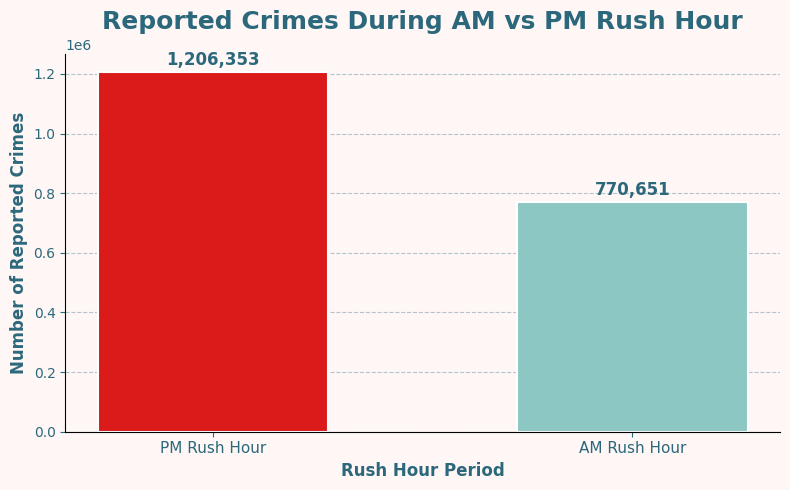

In [ ]:
RED = "#DB1A1A"
BG = "#FFF6F6"
TEAL = "#8CC7C4"
DARK_TEAL = "#2C687B"

fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
ax.set_facecolor(BG)

colors = [TEAL if label == "AM Rush Hour" else RED for label in rush_counts.index]

bars = ax.bar(
    rush_counts.index,
    rush_counts.values,
    color=colors,
    edgecolor="white",
    linewidth=1.5,
    width=0.55
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + rush_counts.max()*0.02,
        f"{int(height):,}",
        ha="center",
        fontsize=12,
        fontweight="bold",
        color=DARK_TEAL
    )

ax.set_title(
    "Reported Crimes During AM vs PM Rush Hour",
    fontsize=18,
    fontweight="bold",
    color=DARK_TEAL,
    pad=18
)

ax.set_ylabel("Number of Reported Crimes", fontsize=12, color=DARK_TEAL, fontweight="bold")
ax.set_xlabel("Rush Hour Period", fontsize=12, color=DARK_TEAL, fontweight="bold")

ax.grid(axis="y", linestyle="--", alpha=0.35, color=DARK_TEAL)
ax.set_axisbelow(True)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.tick_params(axis="x", colors=DARK_TEAL, labelsize=11)
ax.tick_params(axis="y", colors=DARK_TEAL)

plt.tight_layout()
plt.show()

#Top 5 crimes in AM Rush Hour

In [ ]:
am_top5 = (
    rush_df[rush_df["Rush Hour"] == "AM Rush Hour"]["Primary Type"]
    .value_counts()
    .head(5)
)

am_top5

,count
Primary Type,
THEFT,185239
BATTERY,108199
CRIMINAL DAMAGE,81281
BURGLARY,73999
OTHER OFFENSE,62453


#Top 5 crimes in PM Rush Hour

In [ ]:
pm_top5 = (
    rush_df[rush_df["Rush Hour"] == "PM Rush Hour"]["Primary Type"]
    .value_counts()
    .head(5)
)

pm_top5

,count
Primary Type,
THEFT,293514
BATTERY,213002
CRIMINAL DAMAGE,134101
NARCOTICS,103032
ASSAULT,89600


#Top 5 AM vs PM

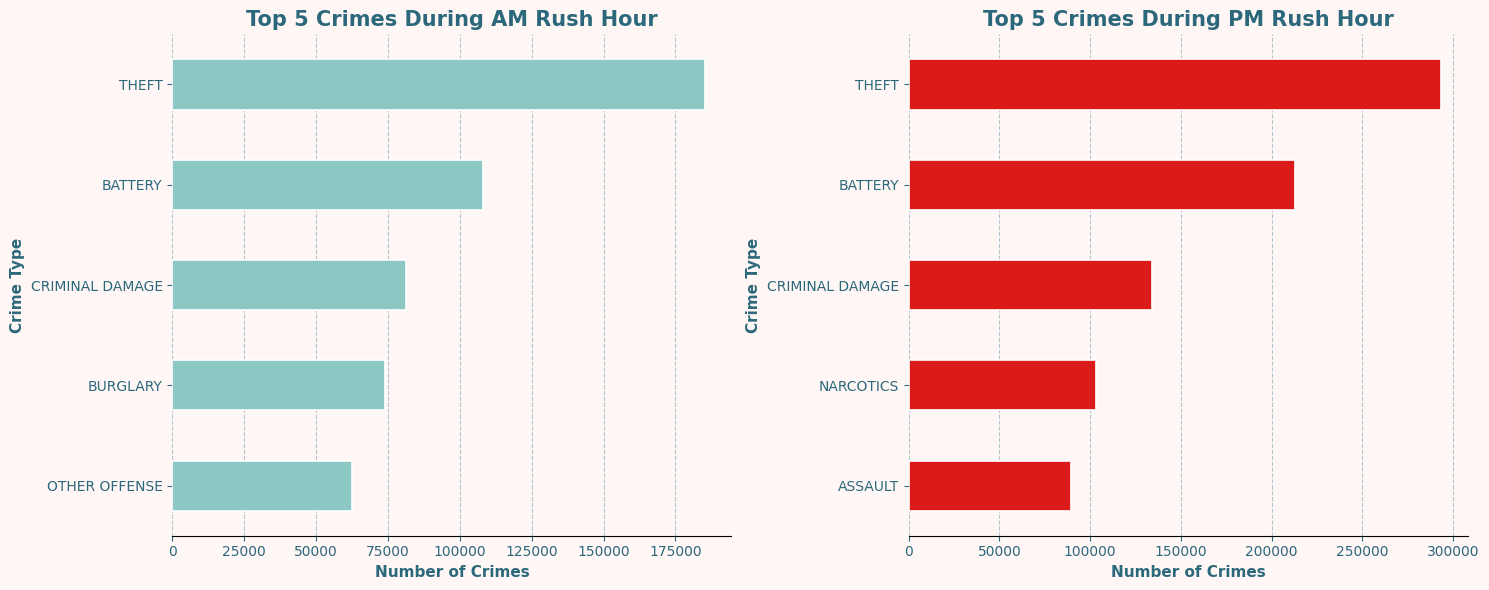

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), facecolor=BG)

for ax in axes:
    ax.set_facecolor(BG)

# AM chart
am_top5.sort_values().plot(
    kind="barh",
    ax=axes[0],
    color=TEAL,
    edgecolor="white",
    linewidth=1.2
)

axes[0].set_title("Top 5 Crimes During AM Rush Hour", fontsize=15, fontweight="bold", color=DARK_TEAL)
axes[0].set_xlabel("Number of Crimes", fontsize=11, color=DARK_TEAL, fontweight="bold")
axes[0].set_ylabel("Crime Type", fontsize=11, color=DARK_TEAL, fontweight="bold")

# PM chart
pm_top5.sort_values().plot(
    kind="barh",
    ax=axes[1],
    color=RED,
    edgecolor="white",
    linewidth=1.2
)

axes[1].set_title("Top 5 Crimes During PM Rush Hour", fontsize=15, fontweight="bold", color=DARK_TEAL)
axes[1].set_xlabel("Number of Crimes", fontsize=11, color=DARK_TEAL, fontweight="bold")
axes[1].set_ylabel("Crime Type", fontsize=11, color=DARK_TEAL, fontweight="bold")

for ax in axes:
    ax.grid(axis="x", linestyle="--", alpha=0.35, color=DARK_TEAL)
    ax.set_axisbelow(True)

    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)

    ax.tick_params(axis="x", colors=DARK_TEAL)
    ax.tick_params(axis="y", colors=DARK_TEAL)

plt.tight_layout()
plt.show()

##Motor Vehicle Theft: AM or PM more?

In [ ]:
motor_vehicle_theft = rush_df[
    rush_df["Primary Type"] == "MOTOR VEHICLE THEFT"
]["Rush Hour"].value_counts()

motor_vehicle_theft

,count
Rush Hour,
PM Rush Hour,53716
AM Rush Hour,41578


##Visulization

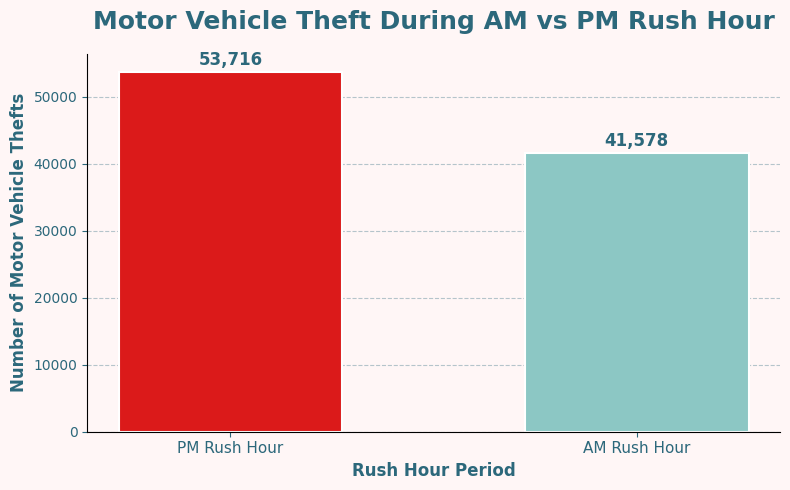

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
ax.set_facecolor(BG)

colors = [TEAL if label == "AM Rush Hour" else RED for label in motor_vehicle_theft.index]

bars = ax.bar(
    motor_vehicle_theft.index,
    motor_vehicle_theft.values,
    color=colors,
    edgecolor="white",
    linewidth=1.5,
    width=0.55
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + motor_vehicle_theft.max()*0.02,
        f"{int(height):,}",
        ha="center",
        fontsize=12,
        fontweight="bold",
        color=DARK_TEAL
    )

ax.set_title(
    "Motor Vehicle Theft During AM vs PM Rush Hour",
    fontsize=18,
    fontweight="bold",
    color=DARK_TEAL,
    pad=18
)

ax.set_ylabel("Number of Motor Vehicle Thefts", fontsize=12, color=DARK_TEAL, fontweight="bold")
ax.set_xlabel("Rush Hour Period", fontsize=12, color=DARK_TEAL, fontweight="bold")

ax.grid(axis="y", linestyle="--", alpha=0.35, color=DARK_TEAL)
ax.set_axisbelow(True)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.tick_params(axis="x", colors=DARK_TEAL, labelsize=11)
ax.tick_params(axis="y", colors=DARK_TEAL)

plt.tight_layout()
plt.show()

## Topic 3: Comparing AM vs PM Rush Hour

This analysis compares reported crimes during morning and evening rush hours in Chicago.

For this project:

* **AM Rush Hour** includes crimes from **7:00 AM to before 10:00 AM**.
* **PM Rush Hour** includes crimes from **4:00 PM to before 7:00 PM**.

The results show that crimes are more common during **PM Rush Hour**. There were **1,206,353 reported crimes** during PM rush hour, compared to **770,651 reported crimes** during AM rush hour.

The top 5 most common crimes during **AM Rush Hour** were:

1. **Theft**
2. **Battery**
3. **Criminal Damage**
4. **Burglary**
5. **Other Offense**

The top 5 most common crimes during **PM Rush Hour** were:

1. **Theft**
2. **Battery**
3. **Criminal Damage**
4. **Narcotics**
5. **Assault**

For **Motor Vehicle Theft**, the crime was also more common during **PM Rush Hour**, with **53,716 cases**, compared to **41,578 cases** during AM Rush Hour.

Overall, the analysis shows that PM rush hour has higher crime activity than AM rush hour, both in total reported crimes and in Motor Vehicle Theft.


#**Topic 4: Comparing Holidays**

##What are the top 3 holidays with the largest number of crimes?

##For each of the top 3 holidays with the most crime, what are the top 5 most common crimes on that holiday?

##We add the fault to the data

In [ ]:
!pip install holidays -q

from holidays import country_holidays

# Create U.S. holidays object
us_holidays = country_holidays("US")

# Create a date-only column from the datetime index
df["DateOnly"] = df.index.date

# Create a holiday lookup dictionary for unique dates only
unique_dates = df["DateOnly"].unique()
holiday_map = {date: us_holidays.get(date) for date in unique_dates}

# Add holiday name to each row
df["Holiday"] = df["DateOnly"].map(holiday_map)

df[["Primary Type", "DateOnly", "Holiday"]].head()

,Primary Type,DateOnly,Holiday
Datetime,,,
2001-01-01,THEFT,2001-01-01,New Year's Day
2001-01-01,THEFT,2001-01-01,New Year's Day
2001-01-01,OFFENSE INVOLVING CHILDREN,2001-01-01,New Year's Day
2001-01-01,THEFT,2001-01-01,New Year's Day
2001-01-01,SEX OFFENSE,2001-01-01,New Year's Day


##We only filter crimes that occurred during the holiday.

In [ ]:
holiday_df = df.dropna(subset=["Holiday"]).copy()

holiday_df[["Primary Type", "Holiday"]].head()

,Primary Type,Holiday
Datetime,,
2001-01-01,THEFT,New Year's Day
2001-01-01,THEFT,New Year's Day
2001-01-01,OFFENSE INVOLVING CHILDREN,New Year's Day
2001-01-01,THEFT,New Year's Day
2001-01-01,SEX OFFENSE,New Year's Day


##We are checking how many crimes occurred during the holidays:

In [ ]:
holiday_df.shape

(227138, 19)

##Top 3 holidays with crime incidents

In [ ]:
top_holidays = holiday_df["Holiday"].value_counts().head(3)

top_holidays

,count
Holiday,
New Year's Day,32725
Independence Day,22672
Labor Day,22164


## Visulizatio of the top 3 holidays

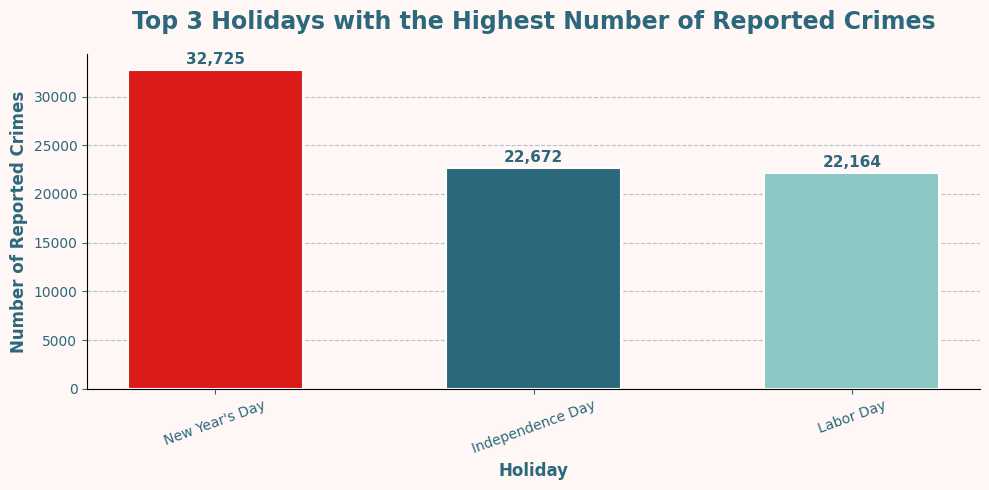

In [ ]:
RED = "#DB1A1A"
BG = "#FFF6F6"
TEAL = "#8CC7C4"
DARK_TEAL = "#2C687B"

fig, ax = plt.subplots(figsize=(10, 5), facecolor=BG)
ax.set_facecolor(BG)

colors = [RED, DARK_TEAL, TEAL]

bars = ax.bar(
    top_holidays.index,
    top_holidays.values,
    color=colors,
    edgecolor="white",
    linewidth=1.5,
    width=0.55
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + top_holidays.max()*0.02,
        f"{int(height):,}",
        ha="center",
        fontsize=11,
        fontweight="bold",
        color=DARK_TEAL
    )

ax.set_title(
    "Top 3 Holidays with the Highest Number of Reported Crimes",
    fontsize=17,
    fontweight="bold",
    color=DARK_TEAL,
    pad=18
)

ax.set_xlabel("Holiday", fontsize=12, color=DARK_TEAL, fontweight="bold")
ax.set_ylabel("Number of Reported Crimes", fontsize=12, color=DARK_TEAL, fontweight="bold")

ax.grid(axis="y", linestyle="--", alpha=0.35, color=DARK_TEAL)
ax.set_axisbelow(True)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.tick_params(axis="x", colors=DARK_TEAL, labelrotation=20)
ax.tick_params(axis="y", colors=DARK_TEAL)

plt.tight_layout()
plt.show()

##The top 5 most common crimes during each holiday, from the top 3

In [ ]:
top_holiday_names = top_holidays.index

top5_crimes_by_holiday = {}

for holiday in top_holiday_names:
    top5 = (
        holiday_df[holiday_df["Holiday"] == holiday]["Primary Type"]
        .value_counts()
        .head(5)
    )
    top5_crimes_by_holiday[holiday] = top5
    print(f"\nTop 5 crimes on {holiday}:")
    display(top5)


Top 5 crimes on New Year's Day:


,count
Primary Type,
THEFT,6845
BATTERY,6043
CRIMINAL DAMAGE,3236
DECEPTIVE PRACTICE,2934
OFFENSE INVOLVING CHILDREN,2380



Top 5 crimes on Independence Day:


,count
Primary Type,
BATTERY,5805
THEFT,4074
CRIMINAL DAMAGE,3309
ASSAULT,1547
NARCOTICS,1522



Top 5 crimes on Labor Day:


,count
Primary Type,
BATTERY,4607
THEFT,4520
CRIMINAL DAMAGE,2475
NARCOTICS,2078
ASSAULT,1525


## Visulizatio for Top 5 for every holiday

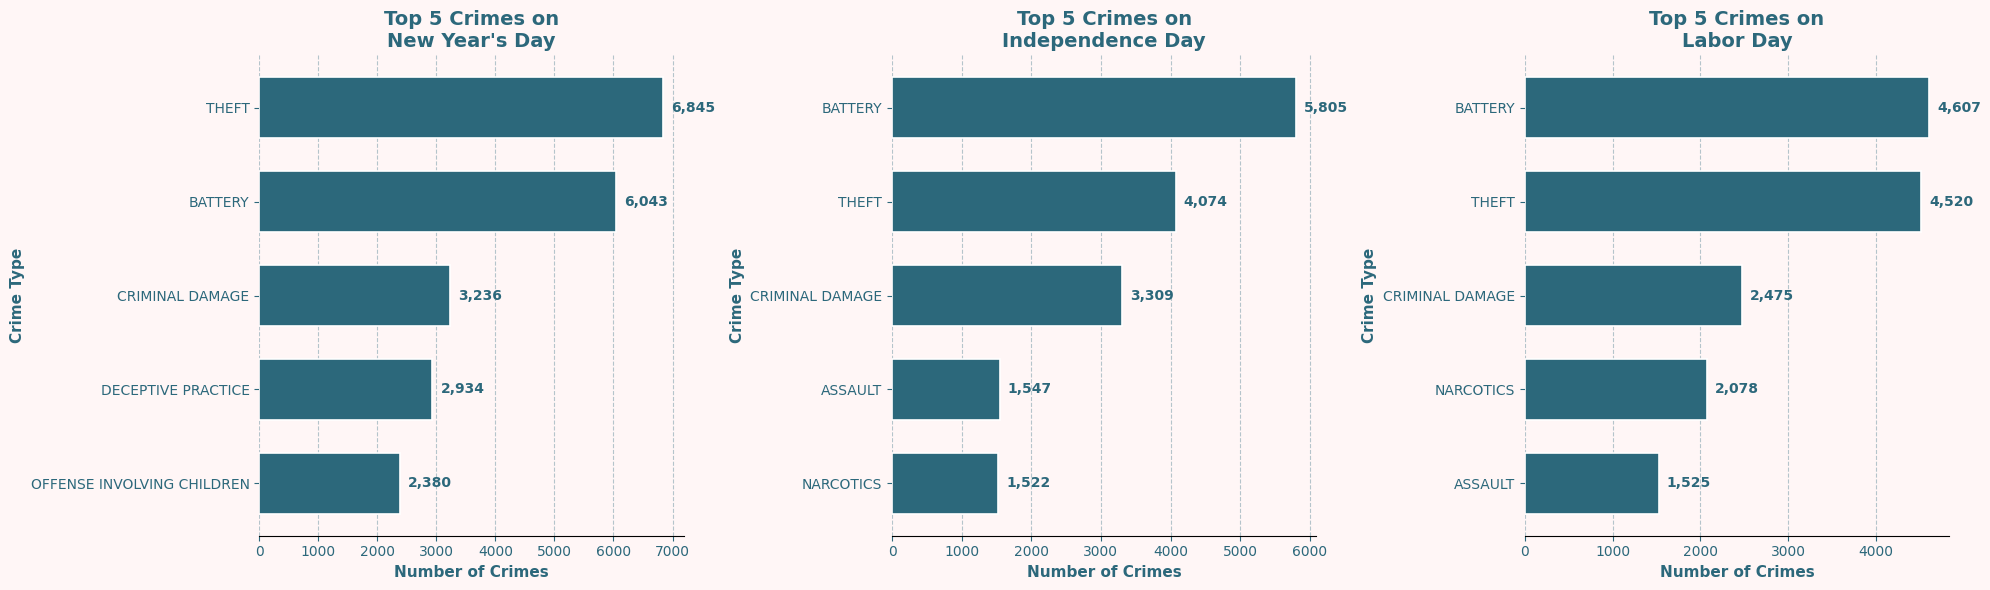

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), facecolor=BG)

for ax, holiday in zip(axes, top_holiday_names):
    ax.set_facecolor(BG)

    data = top5_crimes_by_holiday[holiday].sort_values()

    ax.barh(
        data.index,
        data.values,
        color=DARK_TEAL,
        edgecolor="white",
        linewidth=1.2,
        height=0.65
    )

    for i, value in enumerate(data.values):
        ax.text(
            value + data.max()*0.02,
            i,
            f"{int(value):,}",
            va="center",
            fontsize=10,
            fontweight="bold",
            color=DARK_TEAL
        )

    ax.set_title(
        f"Top 5 Crimes on\n{holiday}",
        fontsize=14,
        fontweight="bold",
        color=DARK_TEAL
    )

    ax.set_xlabel("Number of Crimes", fontsize=11, color=DARK_TEAL, fontweight="bold")
    ax.set_ylabel("Crime Type", fontsize=11, color=DARK_TEAL, fontweight="bold")

    ax.grid(axis="x", linestyle="--", alpha=0.35, color=DARK_TEAL)
    ax.set_axisbelow(True)

    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)

    ax.tick_params(axis="x", colors=DARK_TEAL)
    ax.tick_params(axis="y", colors=DARK_TEAL)

plt.tight_layout()
plt.show()

## Topic 4: Comparing Holidays

This analysis examines reported crimes that occurred on U.S. holidays in Chicago. The holiday feature was added using the `holidays` package, then the data was filtered to include only crimes reported on holidays.

The top 3 holidays with the highest number of reported crimes were:

1. **New Year's Day** with **32,725 crimes**
2. **Independence Day** with **22,672 crimes**
3. **Labor Day** with **22,164 crimes**

For **New Year's Day**, the top 5 most common crimes were:

* **Theft:** 6,845
* **Battery:** 6,043
* **Criminal Damage:** 3,236
* **Deceptive Practice:** 2,934
* **Offense Involving Children:** 2,380

For **Independence Day**, the top 5 most common crimes were:

* **Battery:** 5,805
* **Theft:** 4,074
* **Criminal Damage:** 3,309
* **Assault:** 1,547
* **Narcotics:** 1,522

For **Labor Day**, the top 5 most common crimes were:

* **Battery:** 4,607
* **Theft:** 4,520
* **Criminal Damage:** 2,475
* **Narcotics:** 2,078
* **Assault:** 1,525

Overall, **New Year's Day had the highest number of reported crimes** among all holidays. Theft was the most common crime on New Year's Day, while Battery was the most common crime on both Independence Day and Labor Day.


# Overall Conclusion

This project analyzed reported crime incidents in Chicago from 2001 to 2022 using time series analysis techniques. The goal was to answer stakeholder questions for a local newspaper reporter and support the findings with clear visualizations.

The analysis showed several important findings:

1. **Police Districts:**
   In 2022, crime was not evenly distributed across police districts. District 8 had the highest number of reported crimes, while District 31 had the lowest.

2. **Crime Trends Across the Years:**
   Total reported crimes decreased significantly from 2001 to 2022. Reported crimes dropped from 485,886 in 2001 to 238,858 in 2022, which is about a 50.84% decrease. However, some crime types increased despite the overall decline, such as Weapons Violation, Deceptive Practice, Criminal Sexual Assault, and Homicide.

3. **AM vs PM Rush Hour:**
   Crimes were more common during PM rush hour than AM rush hour. Theft was the most common crime during both periods. Motor Vehicle Theft was also more common during PM rush hour.

4. **Holidays:**
   New Year's Day had the highest number of reported crimes among holidays, followed by Independence Day and Labor Day. Theft was the most common crime on New Year's Day, while Battery was the most common crime on Independence Day and Labor Day.

Overall, this project shows that crime patterns in Chicago vary by time, location, crime type, and special calendar events. Time series analysis helped turn raw crime records into meaningful insights that can support public reporting and stakeholder decision-making.


**In addition to the original crime-level dataset, I created a daily resampled version where each row represents one day and the value represents the total number of reported crimes on that day.**

In [ ]:
daily_counts = df.resample("D").size().to_frame("Total Crimes")

daily_counts.head()

,Total Crimes
Datetime,
2001-01-01,1825
2001-01-02,1143
2001-01-03,1151
2001-01-04,1166
2001-01-05,1267


#**Project 3 - Part 2**

##Create Monthly Crime Counts

In [ ]:
# Selected crimes for Project 3 - Part 2
selected_crimes = ["THEFT", "NARCOTICS"]

# Create monthly crime count time series for Theft
theft_ts = (
    df[df["Primary Type"] == "THEFT"]
    .resample("MS")
    .size()
)

# Create monthly crime count time series for Narcotics
narcotics_ts = (
    df[df["Primary Type"] == "NARCOTICS"]
    .resample("MS")
    .size()
)

# Combine both time series in one DataFrame for easy comparison
monthly_crimes = pd.DataFrame({
    "Theft": theft_ts,
    "Narcotics": narcotics_ts
})

monthly_crimes.head()

,Theft,Narcotics
Datetime,,
2001-01-01,7867,4714
2001-02-01,6669,4369
2001-03-01,7766,4862
2001-04-01,7702,4044
2001-05-01,8420,4038


##Check Null Values

In [ ]:
# Check for null values
monthly_crimes.isna().sum()

,0
Theft,0
Narcotics,0


## Visualization

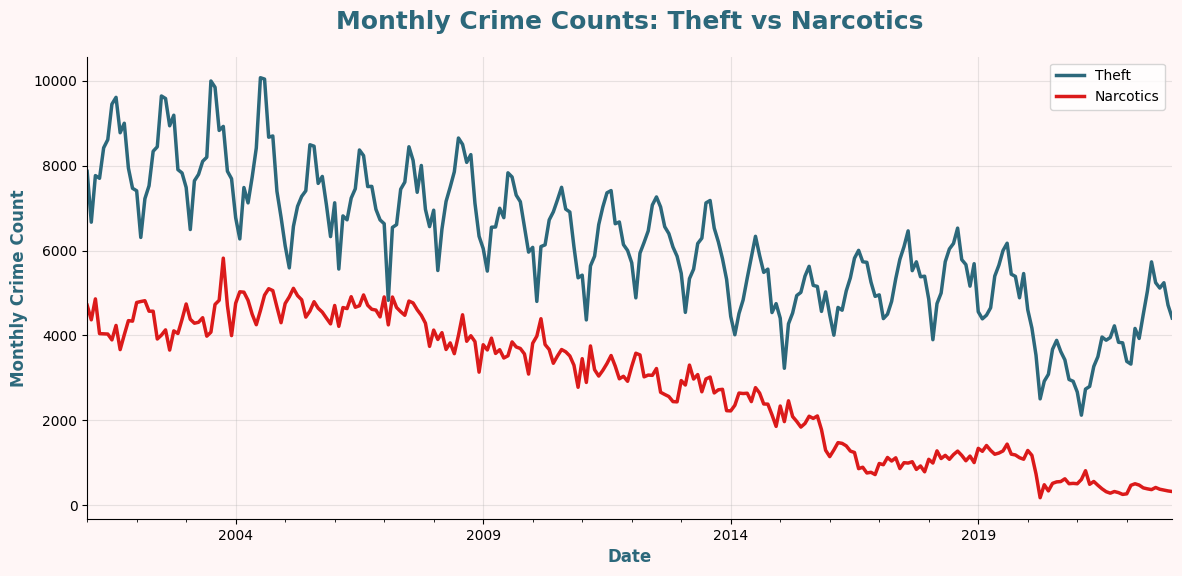

In [ ]:
import matplotlib.pyplot as plt

RED = "#DB1A1A"
BG = "#FFF6F6"
TEAL = "#8CC7C4"
DARK_TEAL = "#2C687B"

fig, ax = plt.subplots(figsize=(14, 6), facecolor=BG)
ax.set_facecolor(BG)

monthly_crimes["Theft"].plot(ax=ax, color=DARK_TEAL, linewidth=2.5, label="Theft")
monthly_crimes["Narcotics"].plot(ax=ax, color=RED, linewidth=2.5, label="Narcotics")

ax.set_title("Monthly Crime Counts: Theft vs Narcotics", fontsize=18, fontweight="bold", color=DARK_TEAL, pad=20)
ax.set_xlabel("Date", fontsize=12, color=DARK_TEAL, fontweight="bold")
ax.set_ylabel("Monthly Crime Count", fontsize=12, color=DARK_TEAL, fontweight="bold")

ax.legend()
ax.grid(alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

##Decomposition

In [ ]:
import statsmodels.tsa.api as tsa

# Make sure frequency is monthly start
theft_ts = theft_ts.asfreq("MS")
narcotics_ts = narcotics_ts.asfreq("MS")

In [ ]:
import matplotlib.pyplot as plt
import statsmodels.tsa.api as tsa

RED = "#DB1A1A"
BG = "#FFF6F6"
TEAL = "#8CC7C4"
DARK_TEAL = "#2C687B"

def plot_decomposition_custom(ts, title):
    decomp = tsa.seasonal_decompose(ts, model="additive", period=12)

    fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True, facecolor=BG)
    fig.patch.set_facecolor(BG)

    components = [
        (ts, "Observed", DARK_TEAL),
        (decomp.trend, "Trend", DARK_TEAL),
        (decomp.seasonal, "Seasonal", TEAL),
        (decomp.resid, "Residual", RED)
    ]

    for ax, (data, label, color) in zip(axes, components):
        ax.set_facecolor(BG)
        ax.plot(data.index, data.values, color=color, linewidth=2)
        ax.set_ylabel(label, fontsize=11, fontweight="bold", color=DARK_TEAL)
        ax.grid(alpha=0.3)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_color(DARK_TEAL)
        ax.spines["bottom"].set_color(DARK_TEAL)
        ax.tick_params(colors=DARK_TEAL)

    fig.suptitle(title, fontsize=20, fontweight="bold", color=DARK_TEAL, y=1.02)
    plt.tight_layout()
    plt.show()

    return decomp

##Decompose Theft

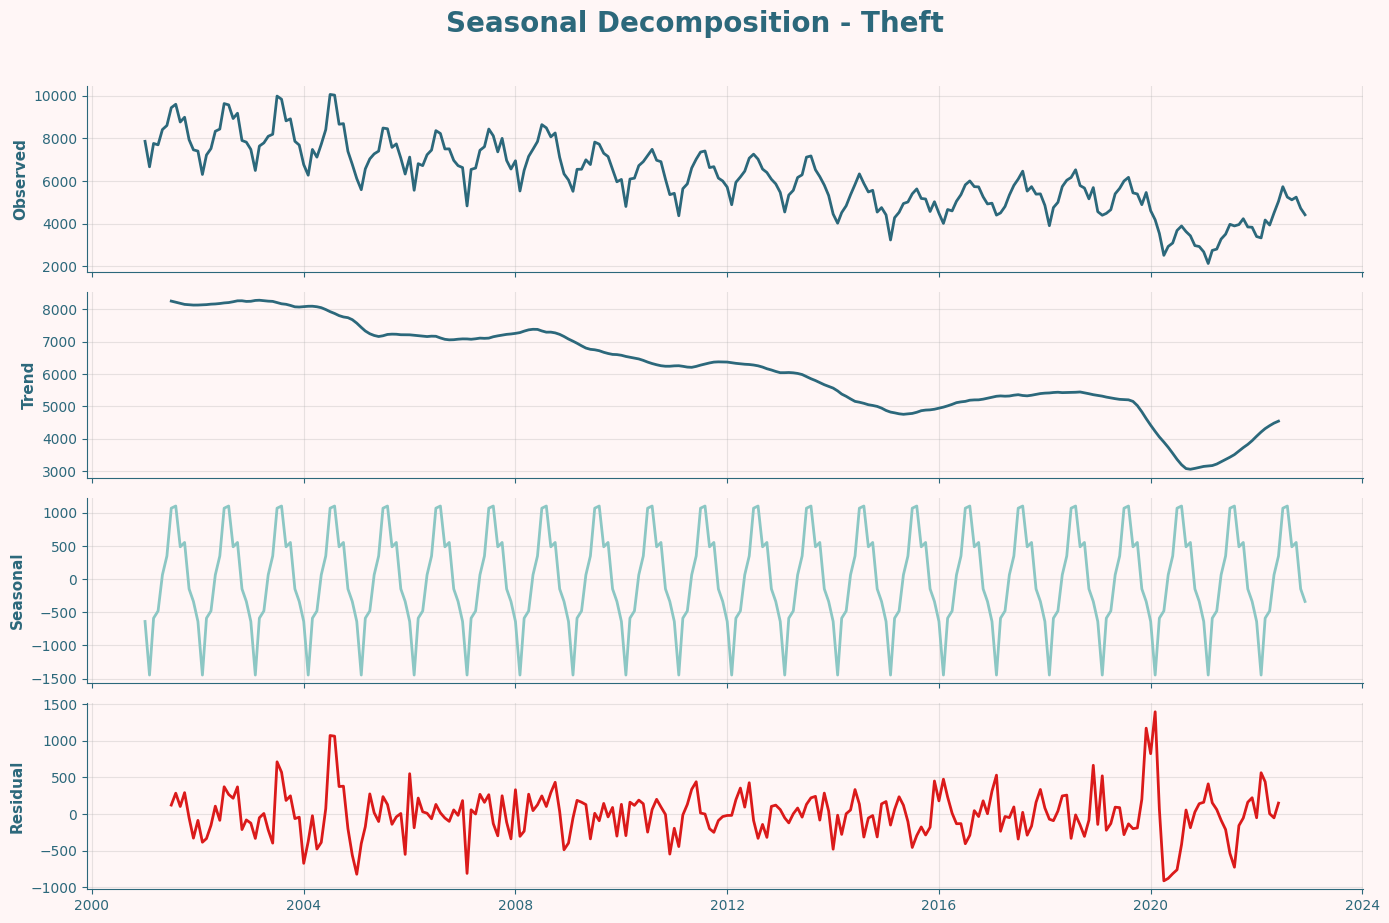

In [ ]:
theft_decomp = plot_decomposition_custom(theft_ts, "Seasonal Decomposition - Theft")

##Decompose Narcotics

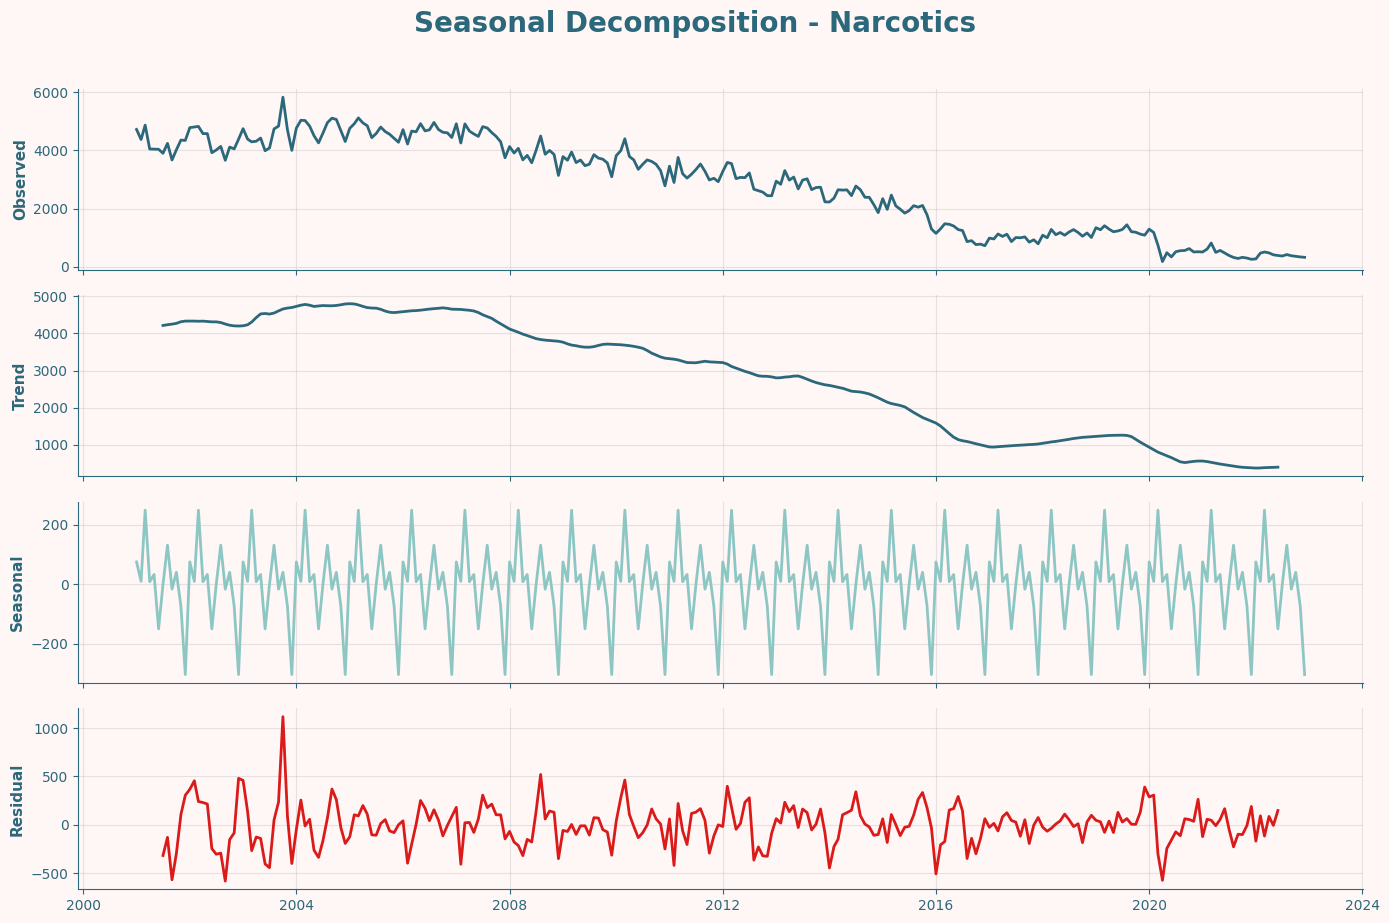

In [ ]:
narcotics_decomp = plot_decomposition_custom(narcotics_ts, "Seasonal Decomposition - Narcotics")

## Seasonal Decomposition

- The seasonal decomposition shows that both selected crimes have trend and seasonal components.


- For Theft, the seasonal component represents about 32.08% of the total variation, which indicates a meaningful yearly seasonal pattern. Therefore, a seasonal model such as SARIMA is appropriate.


- For Narcotics, the seasonal component represents about 9.76% of the total variation. This is weaker than Theft, but the decomposition still shows a repeating yearly pattern, so a seasonal model will also be explored.


- Since the data is monthly, the seasonal period will be set to 12 months.

##Calculate the strength of seasonality

In [ ]:
# Seasonal strength for Theft
theft_seasonal_delta = theft_decomp.seasonal.max() - theft_decomp.seasonal.min()
theft_variation = theft_ts.max() - theft_ts.min()

print(f"Theft seasonal component: {theft_seasonal_delta:.2f}")
print(f"Theft seasonal component is about {(theft_seasonal_delta / theft_variation) * 100:.2f}% of total variation")

Theft seasonal component: 2549.99
Theft seasonal component is about 32.08% of total variation


In [ ]:
# Seasonal strength for Narcotics
narcotics_seasonal_delta = narcotics_decomp.seasonal.max() - narcotics_decomp.seasonal.min()
narcotics_variation = narcotics_ts.max() - narcotics_ts.min()

print(f"Narcotics seasonal component: {narcotics_seasonal_delta:.2f}")
print(f"Narcotics seasonal component is about {(narcotics_seasonal_delta / narcotics_variation) * 100:.2f}% of total variation")

Narcotics seasonal component: 550.66
Narcotics seasonal component is about 9.76% of total variation


##Determine Differencing

In [ ]:
pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 12.5 MB/s eta 0:00:00


In [ ]:
from pmdarima.arima.utils import ndiffs, nsdiffs

m = 12

# Theft differencing
theft_d = ndiffs(theft_ts)
theft_D = nsdiffs(theft_ts, m=m)

print(f"Theft d = {theft_d}")
print(f"Theft D = {theft_D}")

# Narcotics differencing
narcotics_d = ndiffs(narcotics_ts)
narcotics_D = nsdiffs(narcotics_ts, m=m)

print(f"Narcotics d = {narcotics_d}")
print(f"Narcotics D = {narcotics_D}")

Theft d = 1
Theft D = 0
Narcotics d = 1
Narcotics D = 0


## Differencing

The differencing results show that both Theft and Narcotics require one nonseasonal differencing step.

* Theft: d = 1, D = 0
* Narcotics: d = 1, D = 0

This means that both time series are not stationary in their original form and require regular differencing. However, seasonal differencing is not required for either crime type.


##Next, we create a series differenced version to use in ACF/PACF:

In [ ]:
# Create differenced series for Theft
theft_diff = theft_ts.copy()

if theft_d > 0:
    for i in range(theft_d):
        theft_diff = theft_diff.diff()

if theft_D > 0:
    for i in range(theft_D):
        theft_diff = theft_diff.diff(m)

theft_diff = theft_diff.dropna()

In [ ]:
# Create differenced series for Narcotics
narcotics_diff = narcotics_ts.copy()

if narcotics_d > 0:
    for i in range(narcotics_d):
        narcotics_diff = narcotics_diff.diff()

if narcotics_D > 0:
    for i in range(narcotics_D):
        narcotics_diff = narcotics_diff.diff(m)

narcotics_diff = narcotics_diff.dropna()

##We visualize ACF/PACF to choose the first values ​​for p and q.

In [ ]:
import statsmodels.tsa.api as tsa
import matplotlib.pyplot as plt

def plot_acf_pacf_simple(ts, title, nlags=60):
    fig, axes = plt.subplots(2, 1, figsize=(14, 7), facecolor=BG)
    fig.patch.set_facecolor(BG)

    tsa.graphics.plot_acf(
        ts,
        lags=nlags,
        ax=axes[0],
        vlines_kwargs={"colors": DARK_TEAL, "linewidth": 2}
    )

    tsa.graphics.plot_pacf(
        ts,
        lags=nlags,
        ax=axes[1],
        vlines_kwargs={"colors": DARK_TEAL, "linewidth": 2}
    )

    axes[0].set_title(f"ACF - {title}", fontsize=16, fontweight="bold", color=DARK_TEAL)
    axes[1].set_title(f"PACF - {title}", fontsize=16, fontweight="bold", color=DARK_TEAL)

    for ax in axes:
        ax.set_facecolor(BG)

        # Seasonal lag lines
        for lag in range(12, nlags + 1, 12):
            ax.axvline(lag, color=RED, linestyle="--", alpha=0.6, linewidth=1.5)

        ax.axhline(0, color=DARK_TEAL, linewidth=1)
        ax.grid(alpha=0.25)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_color(DARK_TEAL)
        ax.spines["bottom"].set_color(DARK_TEAL)

        ax.tick_params(colors=DARK_TEAL)

        # Change confidence interval color
        for collection in ax.collections:
            collection.set_facecolor(TEAL)
            collection.set_alpha(0.25)

        # Change marker color
        for line in ax.lines:
            line.set_color(DARK_TEAL)
            line.set_markerfacecolor(DARK_TEAL)
            line.set_markeredgecolor(DARK_TEAL)

    plt.tight_layout()
    plt.show()

#**Theft**

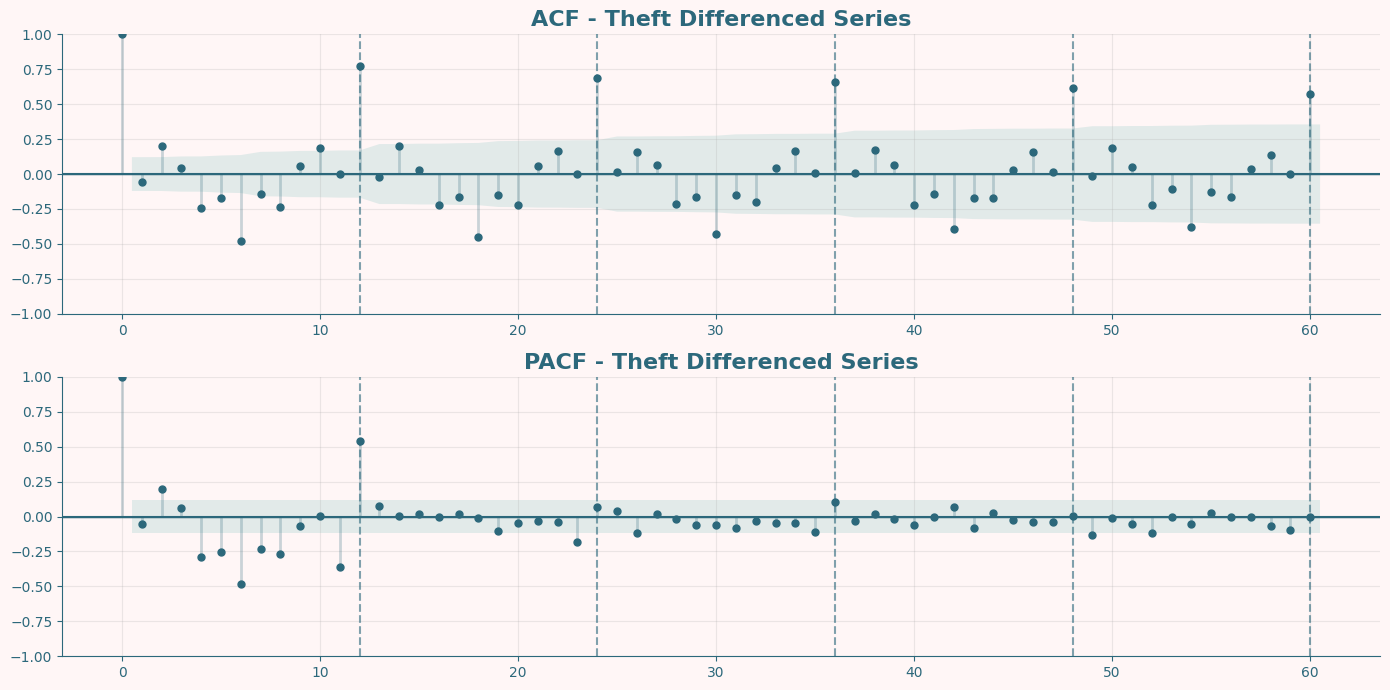

In [ ]:
plot_acf_pacf_simple(theft_diff, "Theft Differenced Series", nlags=60)

#**Narcotics**

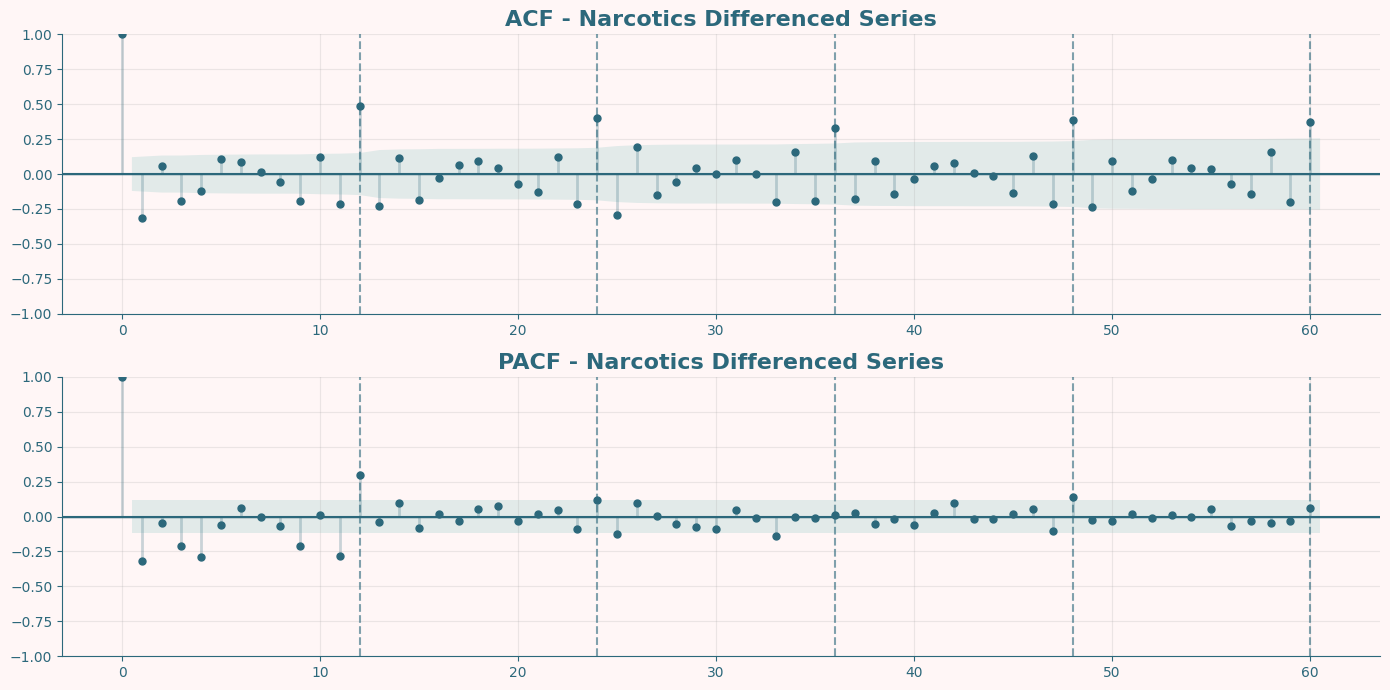

In [ ]:
plot_acf_pacf_simple(narcotics_diff, "Narcotics Differenced Series", nlags=60)

## ACF and PACF Interpretation

- The ACF and PACF plots were used to estimate the initial ARIMA/SARIMA orders.

- For both Theft and Narcotics, the differenced series shows seasonal spikes around lag 12 and its multiples, which supports using a seasonal model with a 12-month seasonal period.

Based on the ACF and PACF patterns, the initial manual model selected for both crime types is:

SARIMA(1,1,1)(1,0,1,12)

This model will be used as the manual baseline model, then compared against an auto_arima model.

##Train/Test Split

In [ ]:
from pmdarima.model_selection import train_test_split

# Split Theft into train and test
theft_train, theft_test = train_test_split(theft_ts, test_size=6)

# Split Narcotics into train and test
narcotics_train, narcotics_test = train_test_split(narcotics_ts, test_size=6)

print("Theft train:", theft_train.index.min(), "to", theft_train.index.max())
print("Theft test:", theft_test.index.min(), "to", theft_test.index.max())

print("Narcotics train:", narcotics_train.index.min(), "to", narcotics_train.index.max())
print("Narcotics test:", narcotics_test.index.min(), "to", narcotics_test.index.max())

Theft train: 2001-01-01 00:00:00 to 2022-06-01 00:00:00
Theft test: 2022-07-01 00:00:00 to 2022-12-01 00:00:00
Narcotics train: 2001-01-01 00:00:00 to 2022-06-01 00:00:00
Narcotics test: 2022-07-01 00:00:00 to 2022-12-01 00:00:00


##Visualize Train/Test

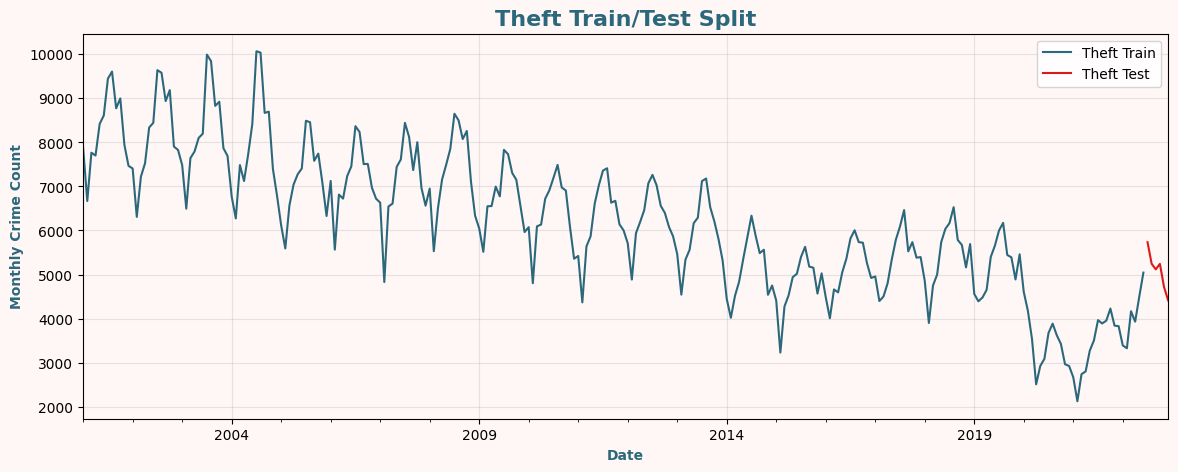

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5), facecolor=BG)
ax.set_facecolor(BG)

theft_train.plot(ax=ax, label="Theft Train", color=DARK_TEAL)
theft_test.plot(ax=ax, label="Theft Test", color=RED)

ax.set_title("Theft Train/Test Split", fontsize=16, fontweight="bold", color=DARK_TEAL)
ax.set_xlabel("Date", color=DARK_TEAL, fontweight="bold")
ax.set_ylabel("Monthly Crime Count", color=DARK_TEAL, fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

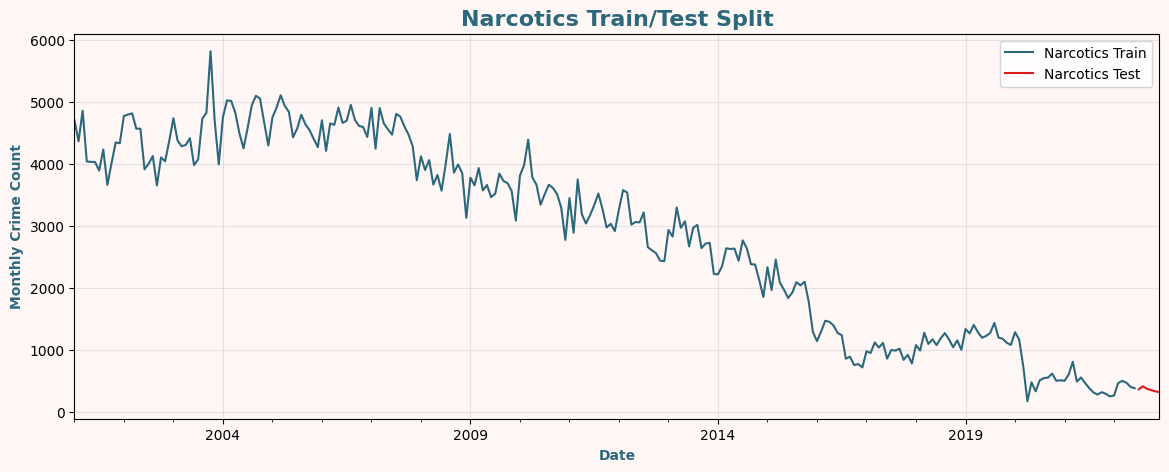

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5), facecolor=BG)
ax.set_facecolor(BG)

narcotics_train.plot(ax=ax, label="Narcotics Train", color=DARK_TEAL)
narcotics_test.plot(ax=ax, label="Narcotics Test", color=RED)

ax.set_title("Narcotics Train/Test Split", fontsize=16, fontweight="bold", color=DARK_TEAL)
ax.set_xlabel("Date", color=DARK_TEAL, fontweight="bold")
ax.set_ylabel("Monthly Crime Count", color=DARK_TEAL, fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## Train/Test Split

The time series data was split using the last 6 months as the test set because the goal is to forecast 6 months ahead.

For both Theft and Narcotics:

- Training period: January 2001 to June 2022
- Testing period: July 2022 to December 2022

This split preserves the time order of the data and allows the model to be evaluated on the most recent observations.


##Manual SARIMA Model

##Function for visulize and evaluting

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np
import statsmodels.tsa.api as tsa

def regression_metrics_ts(y_true, y_pred, label="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    print(f"--- {label} Metrics ---")
    print(f"MAE  = {mae:,.2f}")
    print(f"RMSE = {rmse:,.2f}")
    print(f"MAPE = {mape:,.2f}%")

    return {
        "Model": label,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }


def plot_forecast_custom(train, test, forecast_df, title):
    fig, ax = plt.subplots(figsize=(14, 6), facecolor=BG)
    ax.set_facecolor(BG)

    train.iloc[-48:].plot(ax=ax, label="Train", color=DARK_TEAL, linewidth=2)
    test.plot(ax=ax, label="Test", color=RED, linewidth=2.5)
    forecast_df["mean"].plot(ax=ax, label="Forecast", color=TEAL, linewidth=2.5)

    ax.fill_between(
        forecast_df.index,
        forecast_df["mean_ci_lower"],
        forecast_df["mean_ci_upper"],
        color=TEAL,
        alpha=0.25
    )

    ax.set_title(title, fontsize=18, fontweight="bold", color=DARK_TEAL, pad=18)
    ax.set_xlabel("Date", fontsize=12, color=DARK_TEAL, fontweight="bold")
    ax.set_ylabel("Monthly Crime Count", fontsize=12, color=DARK_TEAL, fontweight="bold")

    ax.legend()
    ax.grid(alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.show()

##Manual SARIMA for Theft

In [ ]:
# Manual SARIMA model for Theft
theft_manual_model = tsa.ARIMA(
    theft_train,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit()

theft_manual_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                    SARIMAX Results                                     
========================================================================================
Dep. Variable:                                y   No. Observations:                  258
Model:             ARIMA(1, 1, 1)x(1, 0, 1, 12)   Log Likelihood               -1745.476
Date:                          Sun, 21 Jun 2026   AIC                           3500.951
Time:                                  05:36:54   BIC                           3518.417
Sample:                              01-01-2001   HQIC                          3507.986
                                   - 06-01-2022                                         
Covariance Type:                            opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0933      0.239      0.390      0.697      -0.376       0.562
ma.L1         -0.3694      0.233     -1.585      0.113      -0.826       0.087
ar.S.L12       0.9560      0.010     94.770      0.000       0.936       0.976
ma.S.L12      -0.7658      0.048    -16.111      0.000      -0.859      -0.673
sigma2      9.633e+04   6257.330     15.395      0.000    8.41e+04    1.09e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                80.32
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):               1.05   Skew:                            -0.57
Prob(H) (two-sided):                  0.83   Kurtosis:                         5.58
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

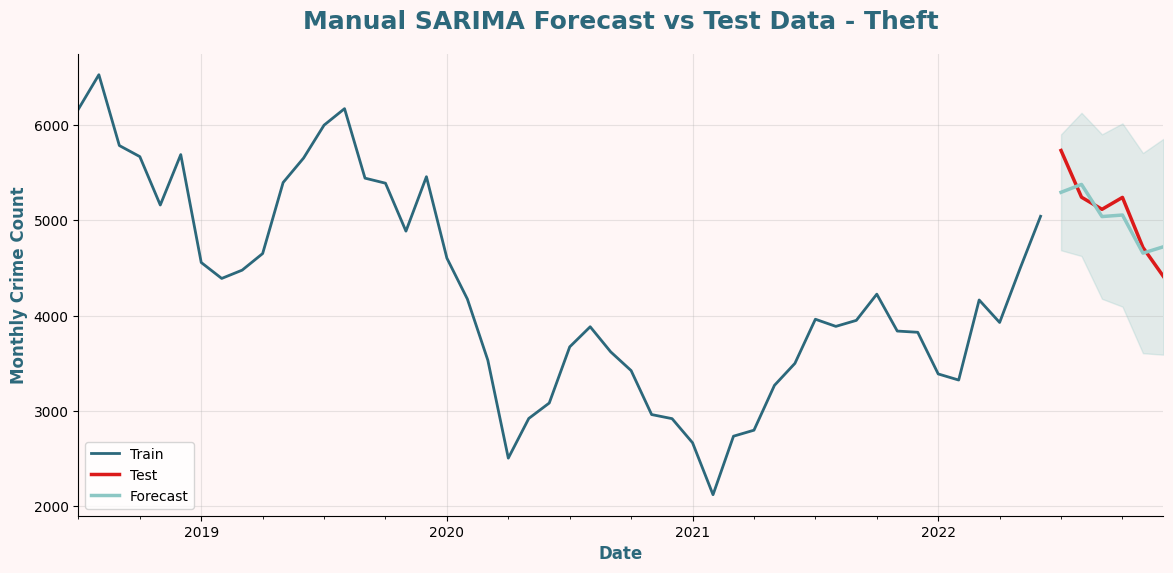

--- Manual SARIMA - Theft Metrics ---
MAE  = 200.67
RMSE = 241.69
MAPE = 3.92%


In [ ]:
# Forecast Theft test period
theft_manual_forecast = theft_manual_model.get_forecast(steps=len(theft_test)).summary_frame()

plot_forecast_custom(
    theft_train,
    theft_test,
    theft_manual_forecast,
    "Manual SARIMA Forecast vs Test Data - Theft"
)

theft_manual_metrics = regression_metrics_ts(
    theft_test,
    theft_manual_forecast["mean"],
    label="Manual SARIMA - Theft"
)

##Manual SARIMA for Narcotics

In [ ]:
# Manual SARIMA model for Narcotics
narcotics_manual_model = tsa.ARIMA(
    narcotics_train,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit()

narcotics_manual_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                    SARIMAX Results                                     
========================================================================================
Dep. Variable:                                y   No. Observations:                  258
Model:             ARIMA(1, 1, 1)x(1, 0, 1, 12)   Log Likelihood               -1665.595
Date:                          Sun, 21 Jun 2026   AIC                           3341.191
Time:                                  05:36:57   BIC                           3358.656
Sample:                              01-01-2001   HQIC                          3348.225
                                   - 06-01-2022                                         
Covariance Type:                            opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5626      0.094      6.011      0.000       0.379       0.746
ma.L1         -0.8174      0.078    -10.475      0.000      -0.970      -0.664
ar.S.L12       0.9201      0.026     35.430      0.000       0.869       0.971
ma.S.L12      -0.7660      0.073    -10.546      0.000      -0.908      -0.624
sigma2      5.067e+04   3511.908     14.428      0.000    4.38e+04    5.76e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.21   Jarque-Bera (JB):                38.83
Prob(Q):                              0.65   Prob(JB):                         0.00
Heteroskedasticity (H):               0.33   Skew:                            -0.39
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.79
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

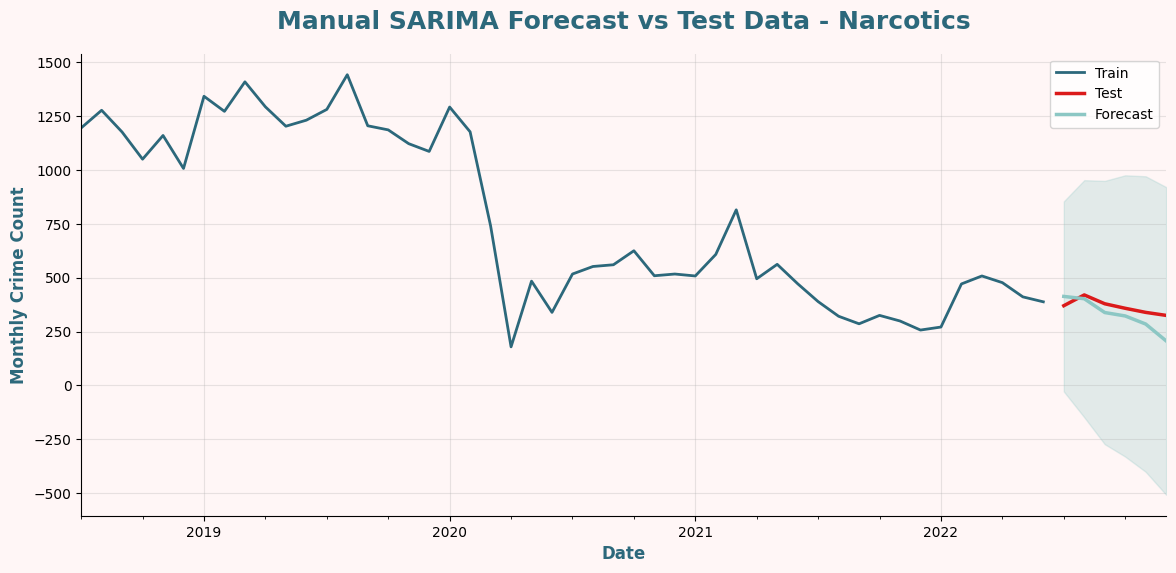

--- Manual SARIMA - Narcotics Metrics ---
MAE  = 51.58
RMSE = 60.59
MAPE = 14.82%


In [ ]:
# Forecast Narcotics test period
narcotics_manual_forecast = narcotics_manual_model.get_forecast(steps=len(narcotics_test)).summary_frame()

plot_forecast_custom(
    narcotics_train,
    narcotics_test,
    narcotics_manual_forecast,
    "Manual SARIMA Forecast vs Test Data - Narcotics"
)

narcotics_manual_metrics = regression_metrics_ts(
    narcotics_test,
    narcotics_manual_forecast["mean"],
    label="Manual SARIMA - Narcotics"
)

##Find the Metrics for Manual Models

In [ ]:
# Manual model metrics summary
theft_manual_metrics = regression_metrics_ts(
    theft_test,
    theft_manual_forecast["mean"],
    label="Manual SARIMA - Theft"
)

narcotics_manual_metrics = regression_metrics_ts(
    narcotics_test,
    narcotics_manual_forecast["mean"],
    label="Manual SARIMA - Narcotics"
)

--- Manual SARIMA - Theft Metrics ---
MAE  = 200.67
RMSE = 241.69
MAPE = 3.92%
--- Manual SARIMA - Narcotics Metrics ---
MAE  = 51.58
RMSE = 60.59
MAPE = 14.82%


In [ ]:
manual_metrics_df = pd.DataFrame([
    theft_manual_metrics,
    narcotics_manual_metrics
])

manual_metrics_df

,Model,MAE,RMSE,MAPE
0,Manual SARIMA - Theft,200.667260,241.691323,3.921054
1,Manual SARIMA - Narcotics,51.577265,60.589229,14.816636


## Manual SARIMA Model Evaluation

A manual SARIMA model was fitted for both selected crime types using the initial orders selected from the ACF and PACF plots.

The manual model used was:

**SARIMA(1,1,1)(1,0,1,12)**

This model includes one nonseasonal differencing step and a 12-month seasonal period because the data is monthly and showed yearly seasonal patterns.

### Manual Model Metrics

| Crime Type |    MAE |   RMSE |   MAPE |
| ---------- | -----: | -----: | -----: |
| Theft      | 200.67 | 241.69 |  3.92% |
| Narcotics  |  51.58 |  60.59 | 14.82% |

### Interpretation

The manual SARIMA model performed well for **Theft**, with a low MAPE of **3.92%**. This means that the model's predictions were close to the actual test values during the 6-month test period.

For **Narcotics**, the model had a higher MAPE of **14.82%**. Although the absolute error was smaller than Theft, the percentage error is higher because Narcotics has much lower monthly crime counts. Smaller count values make percentage-based errors more sensitive.

Overall, the manual SARIMA model provides a useful baseline forecast for both crime types. However, the model will still be compared with an `auto_arima` model to determine whether automated parameter tuning can improve the forecast performance.


##Auto ARIMA for Theft

In [ ]:
import pmdarima as pm

theft_auto_model = pm.auto_arima(
    theft_train,
    seasonal=True,
    m=12,
    d=1,
    D=0,
    start_p=0,
    start_q=0,
    max_p=3,
    max_q=3,
    start_P=0,
    start_Q=0,
    max_P=2,
    max_Q=2,
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True
)

theft_auto_model.summary()

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=4050.524, Time=0.09 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=3791.710, Time=3.35 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=3914.631, Time=2.43 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=4048.603, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=4050.805, Time=0.10 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=3774.214, Time=3.86 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=3743.851, Time=10.90 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=3743.960, Time=1.69 sec
 ARIMA(1,1,0)(2,0,2)[12] intercept   : AIC=inf, Time=2.45 sec
 ARIMA(1,1,0)(1,0,2)[12] intercept   : AIC=3742.901, Time=2.81 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : AIC=3870.719, Time=1.26 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=3913.736, Time=0.42 sec
 ARIMA(0,1,0)(1,0,2)[12] intercept   : AIC=3754.859, Time=2.75 sec
 ARIMA(2,1,0)(1,0,2)[12] intercept   : AIC=3745.673, Time=6.61 sec
 ARIMA(1,1,1)(1,0,2)[12

<class 'statsmodels.iolib.summary.Summary'>
"""
                                        SARIMAX Results                                        
===============================================================================================
Dep. Variable:                                       y   No. Observations:                  258
Model:             SARIMAX(1, 1, 0)x(1, 0, [1, 2], 12)   Log Likelihood               -1865.634
Date:                                 Sun, 21 Jun 2026   AIC                           3741.268
Time:                                         05:38:27   BIC                           3759.013
Sample:                                     01-01-2001   HQIC                          3748.404
                                          - 06-01-2022                                         
Covariance Type:                                   opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2251      0.046     -4.934      0.000      -0.315      -0.136
ar.S.L12       0.9778      0.008    120.055      0.000       0.962       0.994
ma.S.L12      -0.5771      0.059     -9.815      0.000      -0.692      -0.462
ma.S.L24      -0.1202      0.068     -1.758      0.079      -0.254       0.014
sigma2      1.038e+05   7353.336     14.120      0.000    8.94e+04    1.18e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):                30.54
Prob(Q):                              0.87   Prob(JB):                         0.00
Heteroskedasticity (H):               0.80   Skew:                            -0.44
Prob(H) (two-sided):                  0.31   Kurtosis:                         4.44
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

##Forecast Theft using auto_arima

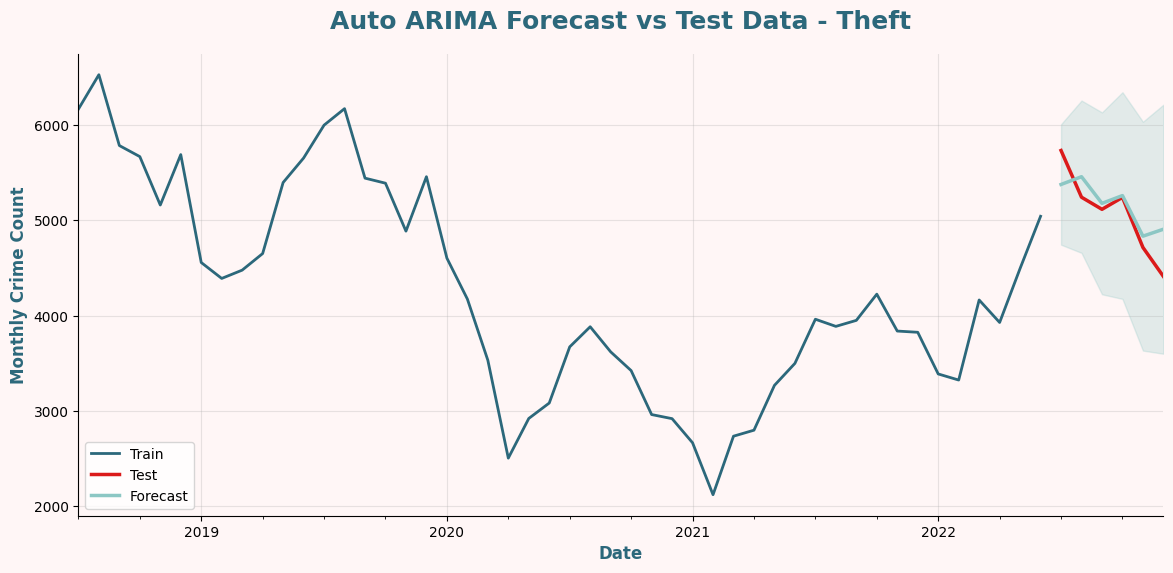

--- Auto ARIMA - Theft Metrics ---
MAE  = 211.16
RMSE = 269.82
MAPE = 4.27%


In [ ]:
# Forecast Theft test period
theft_auto_pred, theft_auto_conf = theft_auto_model.predict(
    n_periods=len(theft_test),
    return_conf_int=True
)

theft_auto_forecast = pd.DataFrame(
    {
        "mean": theft_auto_pred,
        "mean_ci_lower": theft_auto_conf[:, 0],
        "mean_ci_upper": theft_auto_conf[:, 1],
    },
    index=theft_test.index
)

plot_forecast_custom(
    theft_train,
    theft_test,
    theft_auto_forecast,
    "Auto ARIMA Forecast vs Test Data - Theft"
)

theft_auto_metrics = regression_metrics_ts(
    theft_test,
    theft_auto_forecast["mean"],
    label="Auto ARIMA - Theft"
)

##Auto ARIMA for Narcotics

In [ ]:
narcotics_auto_model = pm.auto_arima(
    narcotics_train,
    seasonal=True,
    m=12,
    d=1,
    D=0,
    start_p=0,
    start_q=0,
    max_p=3,
    max_q=3,
    start_P=0,
    start_Q=0,
    max_P=2,
    max_Q=2,
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True
)

narcotics_auto_model.summary()

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=3669.016, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=3583.957, Time=0.63 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=3595.909, Time=0.55 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=3667.813, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=3643.189, Time=0.06 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=3577.354, Time=1.72 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=3559.635, Time=2.77 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=3559.679, Time=1.16 sec
 ARIMA(1,1,0)(2,0,2)[12] intercept   : AIC=inf, Time=6.69 sec
 ARIMA(1,1,0)(1,0,2)[12] intercept   : AIC=3559.353, Time=2.72 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : AIC=3589.825, Time=1.03 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=3602.922, Time=0.40 sec
 ARIMA(0,1,0)(1,0,2)[12] intercept   : AIC=3566.668, Time=2.54 sec
 ARIMA(2,1,0)(1,0,2)[12] intercept   : AIC=3557.629, Time=3.33 sec
 ARIMA(2,1,0)(0,0,2)[12]

<class 'statsmodels.iolib.summary.Summary'>
"""
                                        SARIMAX Results                                        
===============================================================================================
Dep. Variable:                                       y   No. Observations:                  258
Model:             SARIMAX(1, 1, 1)x(1, 0, [1, 2], 12)   Log Likelihood               -1764.369
Date:                                 Sun, 21 Jun 2026   AIC                           3540.738
Time:                                         05:41:36   BIC                           3562.033
Sample:                                     01-01-2001   HQIC                          3549.302
                                          - 06-01-2022                                         
Covariance Type:                                   opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5558      0.084      6.639      0.000       0.392       0.720
ma.L1         -0.8389      0.064    -13.045      0.000      -0.965      -0.713
ar.S.L12       0.9609      0.026     37.395      0.000       0.911       1.011
ma.S.L12      -0.6796      0.080     -8.533      0.000      -0.836      -0.524
ma.S.L24      -0.0995      0.065     -1.540      0.124      -0.226       0.027
sigma2      5.253e+04   3437.684     15.280      0.000    4.58e+04    5.93e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                48.68
Prob(Q):                              0.90   Prob(JB):                         0.00
Heteroskedasticity (H):               0.38   Skew:                            -0.35
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.01
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

##Forecast Narcotics using auto_arima

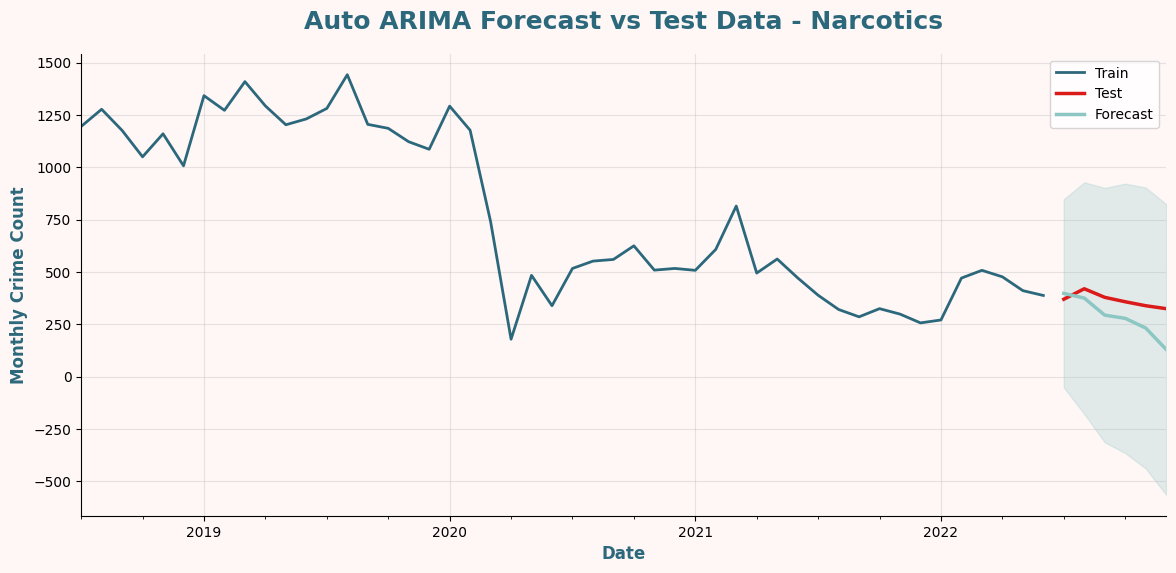

--- Auto ARIMA - Narcotics Metrics ---
MAE  = 89.64
RMSE = 104.44
MAPE = 25.67%


In [ ]:
# Forecast Narcotics test period
narcotics_auto_pred, narcotics_auto_conf = narcotics_auto_model.predict(
    n_periods=len(narcotics_test),
    return_conf_int=True
)

narcotics_auto_forecast = pd.DataFrame(
    {
        "mean": narcotics_auto_pred,
        "mean_ci_lower": narcotics_auto_conf[:, 0],
        "mean_ci_upper": narcotics_auto_conf[:, 1],
    },
    index=narcotics_test.index
)

plot_forecast_custom(
    narcotics_train,
    narcotics_test,
    narcotics_auto_forecast,
    "Auto ARIMA Forecast vs Test Data - Narcotics"
)

narcotics_auto_metrics = regression_metrics_ts(
    narcotics_test,
    narcotics_auto_forecast["mean"],
    label="Auto ARIMA - Narcotics"
)

##Manual vs Auto Comparison Table

In [ ]:
model_comparison_df = pd.DataFrame([
    theft_manual_metrics,
    theft_auto_metrics,
    narcotics_manual_metrics,
    narcotics_auto_metrics
])

model_comparison_df

,Model,MAE,RMSE,MAPE
0,Manual SARIMA - Theft,200.667260,241.691323,3.921054
1,Auto ARIMA - Theft,211.158478,269.824178,4.273283
2,Manual SARIMA - Narcotics,51.577265,60.589229,14.816636
3,Auto ARIMA - Narcotics,89.637294,104.436316,25.667126


##Print the best orders

In [ ]:
print("Theft Auto ARIMA order:", theft_auto_model.order)
print("Theft Auto ARIMA seasonal order:", theft_auto_model.seasonal_order)
print("Theft Auto ARIMA AIC:", theft_auto_model.aic())

print("Narcotics Auto ARIMA order:", narcotics_auto_model.order)
print("Narcotics Auto ARIMA seasonal order:", narcotics_auto_model.seasonal_order)
print("Narcotics Auto ARIMA AIC:", narcotics_auto_model.aic())

Theft Auto ARIMA order: (1, 1, 0)
Theft Auto ARIMA seasonal order: (1, 0, 2, 12)
Theft Auto ARIMA AIC: 3741.267561223804
Narcotics Auto ARIMA order: (1, 1, 1)
Narcotics Auto ARIMA seasonal order: (1, 0, 2, 12)
Narcotics Auto ARIMA AIC: 3540.738440011207


# Manual vs. Auto ARIMA Model Comparison

### 1. Methodology & Evaluation
The predictive performance of the Manual SARIMA model and the Auto ARIMA model was evaluated across two distinct crime categories: Theft and Narcotics.

The models were benchmarked using three standard statistical metrics:
* **MAE** (Mean Absolute Error)
* **RMSE** (Root Mean Squared Error)
* **MAPE** (Mean Absolute Percentage Error)

---

### 2. Performance Metrics Comparison

| Crime Category | Model Type | MAPE (%) | Selection Status |
| :--- | :--- | :---: | :---: |
| **Theft** | **Manual SARIMA** | **3.92%** | Selected Model |
| | Auto ARIMA | 4.27% | |
| **Narcotics** | **Manual SARIMA** | **14.82%** | Selected Model |
| | Auto ARIMA | 25.67% | |

---

### 3. Category Analysis and Findings

#### Theft
* The Manual SARIMA model performed better than the Auto ARIMA model.
* The manual model demonstrated lower MAE and RMSE values.
* This indicates that the manual model's forecasts were closer to the actual test values.

#### Narcotics
* The Manual SARIMA model also outperformed the Auto ARIMA model.
* Although Narcotics has smaller monthly baseline counts, the manual model produced more accurate forecasts.
* Auto ARIMA showed a significantly higher error rate (25.67% compared to 14.82%).

---

### 4. Final Model Selection

Based on the evaluation metrics, the **Manual SARIMA model** was chosen as the final forecasting model for both Theft and Narcotics.

* **Selected Model Architecture:**  
  $$\text{SARIMA}(1,1,1)(1,0,1)_{12}$$

* **Justification:** This specific architecture achieved the lowest overall MAE, RMSE, and MAPE compared to the automated iterations, ensuring the highest predictive accuracy.


##Fit final models on full data

In [ ]:
# Final SARIMA model for Theft using the full time series
theft_final_model = tsa.ARIMA(
    theft_ts,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit()

# Final SARIMA model for Narcotics using the full time series
narcotics_final_model = tsa.ARIMA(
    narcotics_ts,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit()

##Forecast 6 months into the future

In [ ]:
# Forecast 6 months beyond the full dataset
future_steps = 6

theft_future_forecast = theft_final_model.get_forecast(steps=future_steps).summary_frame()
narcotics_future_forecast = narcotics_final_model.get_forecast(steps=future_steps).summary_frame()

theft_future_forecast

y,mean,mean_se,mean_ci_lower,mean_ci_upper
2023-01-01,4120.407537,310.094161,3512.634150,4728.180925
2023-02-01,3742.769131,382.079250,2993.907562,4491.630700
2023-03-01,4141.130026,437.702901,3283.248103,4999.011948
2023-04-01,4069.640427,486.542714,3116.034230,5023.246623
2023-05-01,4509.687741,530.860410,3469.220456,5550.155026
2023-06-01,4771.847921,571.748245,3651.241952,5892.453891


In [ ]:
narcotics_future_forecast

y,mean,mean_se,mean_ci_lower,mean_ci_upper
2023-01-01,406.553650,222.479622,-29.498395,842.605696
2023-02-01,405.648471,277.450147,-138.143824,949.440767
2023-03-01,463.524660,308.079734,-140.300523,1067.349844
2023-04-01,310.754692,329.203148,-334.471622,955.981006
2023-05-01,330.556444,345.838780,-347.275109,1008.387997
2023-06-01,266.016726,360.095931,-439.758330,971.791782


##Plot future forecasts

In [ ]:
def plot_future_forecast(ts, forecast_df, title):
    fig, ax = plt.subplots(figsize=(14, 6), facecolor=BG)
    ax.set_facecolor(BG)

    ts.iloc[-48:].plot(ax=ax, label="Historical Data", color=DARK_TEAL, linewidth=2.5)
    forecast_df["mean"].plot(ax=ax, label="Future Forecast", color=RED, linewidth=2.8)

    ax.fill_between(
        forecast_df.index,
        forecast_df["mean_ci_lower"],
        forecast_df["mean_ci_upper"],
        color=TEAL,
        alpha=0.25
    )

    ax.set_title(title, fontsize=18, fontweight="bold", color=DARK_TEAL, pad=18)
    ax.set_xlabel("Date", fontsize=12, color=DARK_TEAL, fontweight="bold")
    ax.set_ylabel("Monthly Crime Count", fontsize=12, color=DARK_TEAL, fontweight="bold")

    ax.legend()
    ax.grid(alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.show()

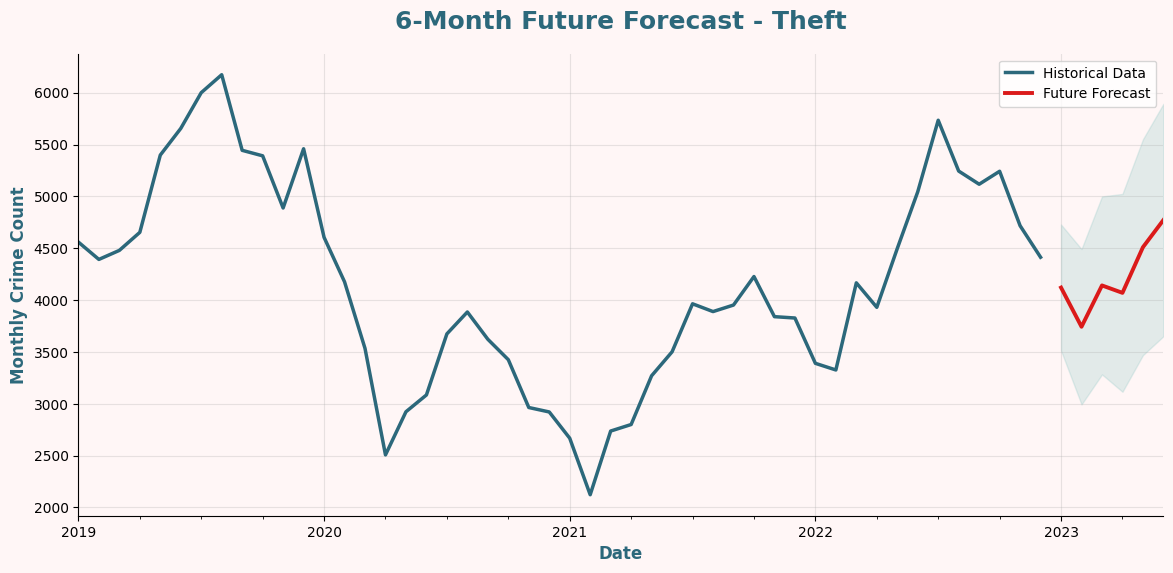

In [ ]:
plot_future_forecast(
    theft_ts,
    theft_future_forecast,
    "6-Month Future Forecast - Theft"
)

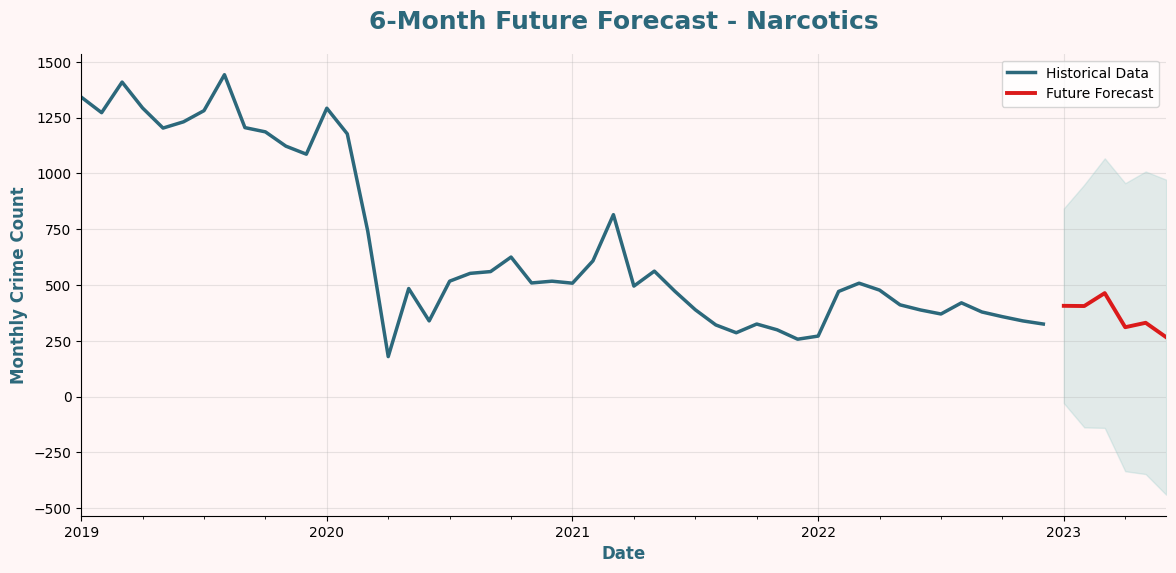

In [ ]:
plot_future_forecast(
    narcotics_ts,
    narcotics_future_forecast,
    "6-Month Future Forecast - Narcotics"
)

##Calculate net change and percent change

In [ ]:
def summarize_future_forecast(forecast_df, crime_name):
    start_date = forecast_df.index[0]
    end_date = forecast_df.index[-1]

    starting_value = forecast_df["mean"].iloc[0]
    final_value = forecast_df["mean"].iloc[-1]

    net_change = final_value - starting_value
    percent_change = (net_change / starting_value) * 100

    print(f"--- {crime_name} Future Forecast Summary ---")
    print(f"Forecast start date: {start_date}")
    print(f"Forecast end date: {end_date}")
    print(f"Starting forecast value: {starting_value:.2f}")
    print(f"Final forecast value: {final_value:.2f}")
    print(f"Net change: {net_change:.2f}")
    print(f"Percent change: {percent_change:.2f}%")

    return {
        "Crime Type": crime_name,
        "Forecast Start": start_date,
        "Forecast End": end_date,
        "Starting Value": starting_value,
        "Final Value": final_value,
        "Net Change": net_change,
        "Percent Change": percent_change
    }

In [ ]:
theft_future_summary = summarize_future_forecast(theft_future_forecast, "Theft")
narcotics_future_summary = summarize_future_forecast(narcotics_future_forecast, "Narcotics")

--- Theft Future Forecast Summary ---
Forecast start date: 2023-01-01 00:00:00
Forecast end date: 2023-06-01 00:00:00
Starting forecast value: 4120.41
Final forecast value: 4771.85
Net change: 651.44
Percent change: 15.81%
--- Narcotics Future Forecast Summary ---
Forecast start date: 2023-01-01 00:00:00
Forecast end date: 2023-06-01 00:00:00
Starting forecast value: 406.55
Final forecast value: 266.02
Net change: -140.54
Percent change: -34.57%


In [ ]:
future_summary_df = pd.DataFrame([
    theft_future_summary,
    narcotics_future_summary
])

future_summary_df

,Crime Type,Forecast Start,Forecast End,Starting Value,Final Value,Net Change,Percent Change
0,Theft,2023-01-01,2023-06-01,4120.407537,4771.847921,651.440384,15.810096
1,Narcotics,2023-01-01,2023-06-01,406.553650,266.016726,-140.536924,-34.567867


## True Future Forecast Summary

After selecting the final model, the manual SARIMA model was refit using the full time series data for each crime type. This step is important because the final future forecast should use all available historical data, not only the training data.

The model was then used to forecast the next 6 months beyond the dataset, from **January 2023 to June 2023**.

### Theft Forecast

For Theft, the forecast starts at approximately **4,120 crimes** in January 2023 and ends at approximately **4,772 crimes** in June 2023.

This represents a predicted net increase of about **651 crimes**, or a **15.81% increase** over the 6-month forecast period.

### Narcotics Forecast

For Narcotics, the forecast starts at approximately **407 crimes** in January 2023 and ends at approximately **266 crimes** in June 2023.

This represents a predicted net decrease of about **141 crimes**, or a **34.57% decrease** over the 6-month forecast period.

### Interpretation

The forecast suggests that **Theft is expected to increase** over the next 6 months, while **Narcotics is expected to decrease**.

This indicates that law enforcement may need to allocate more resources toward Theft-related prevention and response during the forecast period.


## Forecast Change Questions

### Theft

* Predicted net change: **+651.44 crimes**
* Percent change: **+15.81%**

The forecast suggests that Theft is expected to increase from the beginning to the end of the 6-month forecast period.

### Narcotics

* Predicted net change: **-140.54 crimes**
* Percent change: **-34.57%**

The forecast suggests that Narcotics is expected to decrease from the beginning to the end of the 6-month forecast period.


In [ ]:
# Final comparison table
final_evaluation_df = future_summary_df.copy()

final_evaluation_df["Starting Value"] = final_evaluation_df["Starting Value"].round(2)
final_evaluation_df["Final Value"] = final_evaluation_df["Final Value"].round(2)
final_evaluation_df["Net Change"] = final_evaluation_df["Net Change"].round(2)
final_evaluation_df["Percent Change"] = final_evaluation_df["Percent Change"].round(2)

final_evaluation_df

,Crime Type,Forecast Start,Forecast End,Starting Value,Final Value,Net Change,Percent Change
0,Theft,2023-01-01,2023-06-01,4120.41,4771.85,651.44,15.81
1,Narcotics,2023-01-01,2023-06-01,406.55,266.02,-140.54,-34.57


##Reporting-quality visual

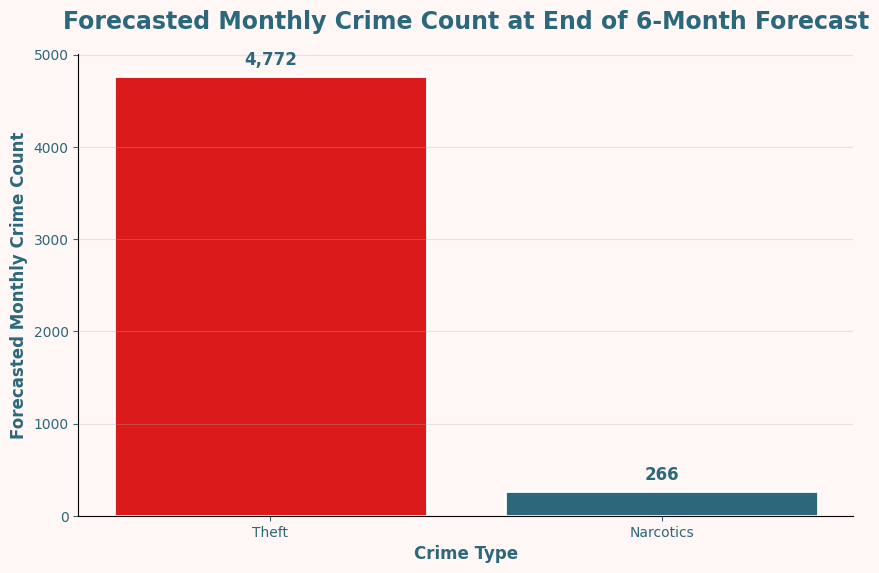

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
ax.set_facecolor(BG)

plot_df = final_evaluation_df.set_index("Crime Type")

bars = ax.bar(
    plot_df.index,
    plot_df["Final Value"],
    color=[RED, DARK_TEAL],
    edgecolor="white",
    linewidth=2
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 80,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
        color=DARK_TEAL
    )

ax.set_title(
    "Forecasted Monthly Crime Count at End of 6-Month Forecast",
    fontsize=17,
    fontweight="bold",
    color=DARK_TEAL,
    pad=18
)

ax.set_xlabel("Crime Type", fontsize=12, fontweight="bold", color=DARK_TEAL)
ax.set_ylabel("Forecasted Monthly Crime Count", fontsize=12, fontweight="bold", color=DARK_TEAL)

ax.grid(axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(colors=DARK_TEAL)

plt.show()

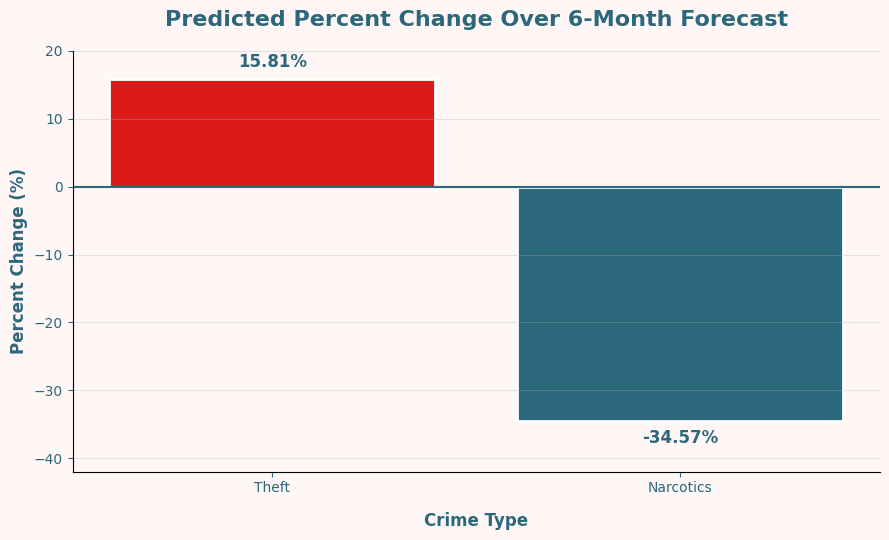

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5.5), facecolor=BG)
ax.set_facecolor(BG)

plot_df = future_summary_df.set_index("Crime Type")

bars = ax.bar(
    plot_df.index,
    plot_df["Percent Change"],
    color=[RED, DARK_TEAL],
    edgecolor="white",
    linewidth=2
)

ax.axhline(0, color=DARK_TEAL, linewidth=1.5)

for bar in bars:
    value = bar.get_height()

    if value >= 0:
        y_pos = value + 1.2
        va = "bottom"
    else:
        y_pos = value - 1.2
        va = "top"

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        y_pos,
        f"{value:.2f}%",
        ha="center",
        va=va,
        fontsize=12,
        fontweight="bold",
        color=DARK_TEAL
    )

ax.set_title(
    "Predicted Percent Change Over 6-Month Forecast",
    fontsize=16,
    fontweight="bold",
    color=DARK_TEAL,
    pad=18
)

ax.set_xlabel("Crime Type", fontsize=12, fontweight="bold", color=DARK_TEAL, labelpad=12)
ax.set_ylabel("Percent Change (%)", fontsize=12, fontweight="bold", color=DARK_TEAL)

# أهم سطر: نعطي مساحة فوق وتحت
ax.set_ylim(-42, 20)

ax.grid(axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(colors=DARK_TEAL)

plt.tight_layout()
plt.show()

## Final Evaluation

After forecasting 6 months into the future, the results show clear differences between Theft and Narcotics.

### Which crime is forecasted to have the highest monthly count at the end of the forecast?

**Theft** is forecasted to have the highest monthly count at the end of the forecast.

* Theft final forecast value: **4,771.85 crimes**
* Narcotics final forecast value: **266.02 crimes**

### Which crime is forecasted to have the highest net change by the end of the forecast?

**Theft** is forecasted to have the highest net change.

* Theft net change: **+651.44 crimes**
* Narcotics net change: **-140.54 crimes**

### Which crime is forecasted to have the highest percent change by the end of the forecast?

**Theft** has the highest positive percent change.

* Theft percent change: **+15.81%**
* Narcotics percent change: **-34.57%**

Although Narcotics has a larger percentage decrease in magnitude, Theft is the crime type forecasted to increase during the 6-month period.


#**Final Recommendation**

# Final Recommendation

### 1. Strategic Resource Allocation
Based on the 6-month predictive forecasts, it is highly recommended that law enforcement agencies prioritize tactical resources toward **Theft-related prevention and response initiatives**.

---

### 2. Comparative Forecast Summary (January 2023 – June 2023)

| Crime Category | Forecasted Trend | Volume Change | Percentage Change | Strategic Priority |
| :--- | :--- | :---: | :---: | :---: |
| **Theft** | 📈 Increase | +651 crimes | **+15.81%** | **High Priority** |
| **Narcotics** | 📉 Decrease | -141 crimes | **-34.57%** | Monitor Only |

---

### 3. Core Empirical Findings
* **Theft Projections:** The model projects a significant upward trajectory for Theft offenses, reaching a substantially higher monthly baseline count compared to Narcotics by the end of the forecast period.
* **Narcotics Projections:** Conversely, Narcotics offenses are expected to contract steadily, showing a projected decrease of approximately 34.57%.

---

### 4. Actionable Law Enforcement Strategies
To mitigate the anticipated rise in Theft offenses, especially during the transition into the summer months, the following data-driven strategies should be implemented:

* **Targeted Patrols:** Increase law enforcement visibility and deployment in verified high-theft sectors and hotspots.
* **Public Awareness Initiatives:** Launch targeted crime prevention campaigns to educate the public on securing property.
* **Proactive Monitoring:** Enhance surveillance and tracking in commercial or residential areas with historically high theft rates.


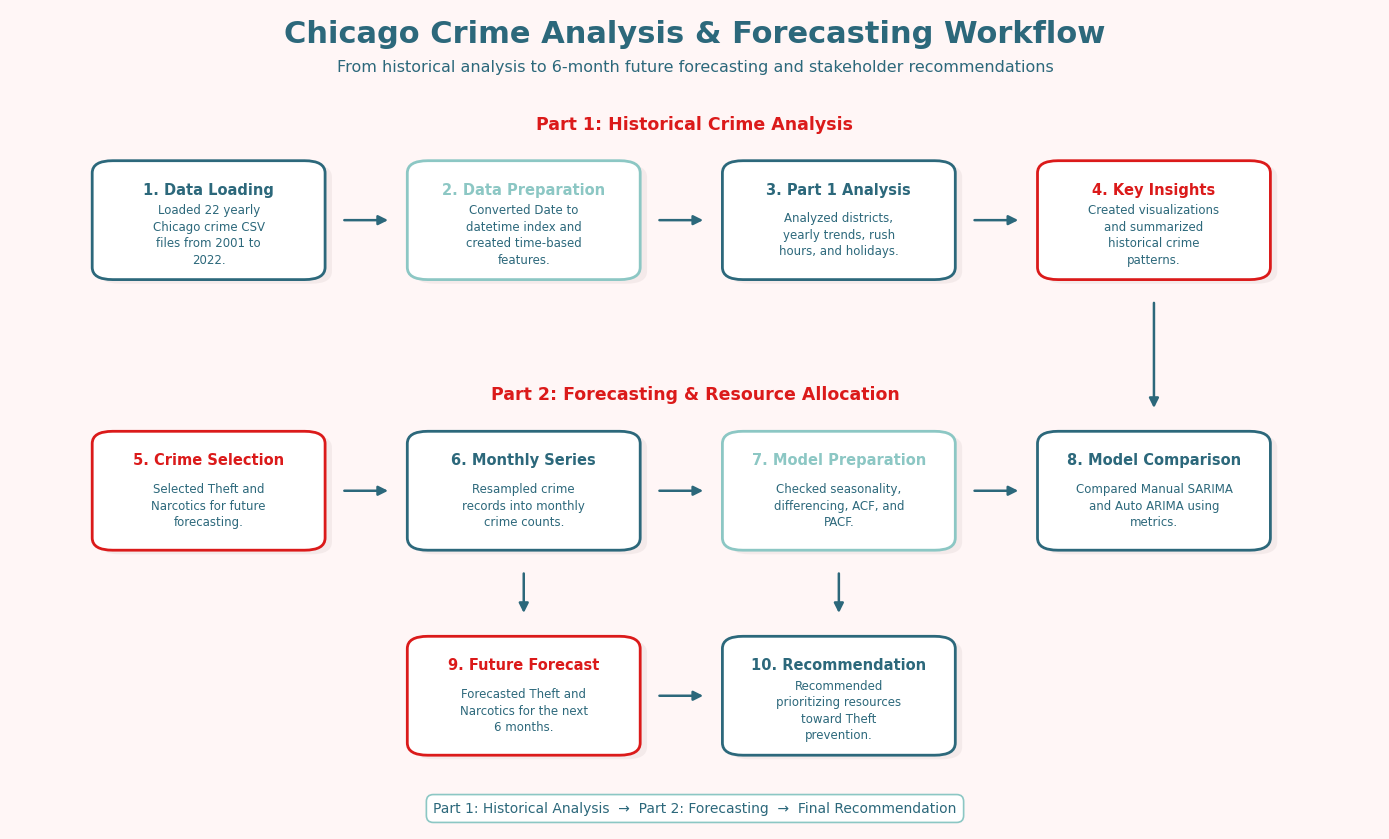

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import textwrap

RED = "#DB1A1A"
BG = "#FFF6F6"
TEAL = "#8CC7C4"
DARK_TEAL = "#2C687B"

fig, ax = plt.subplots(figsize=(14, 8.5), facecolor=BG)
ax.set_facecolor(BG)
ax.axis("off")

def wrap_text(text, width=22):
    return "\n".join(textwrap.wrap(text, width=width))

def draw_box(x, y, title, text, edge_color):
    box_w = 0.17
    box_h = 0.145

    shadow = FancyBboxPatch(
        (x + 0.005, y - 0.005),
        box_w,
        box_h,
        boxstyle="round,pad=0.0,rounding_size=0.015",
        linewidth=0,
        facecolor="#E8DCDC",
        alpha=0.45
    )
    ax.add_patch(shadow)

    box = FancyBboxPatch(
        (x, y),
        box_w,
        box_h,
        boxstyle="round,pad=0.0,rounding_size=0.015",
        linewidth=2.0,
        edgecolor=edge_color,
        facecolor="white"
    )
    ax.add_patch(box)

    ax.text(
        x + box_w / 2,
        y + box_h * 0.76,
        title,
        ha="center",
        va="center",
        fontsize=10.5,
        fontweight="bold",
        color=edge_color
    )

    ax.text(
        x + box_w / 2,
        y + box_h * 0.38,
        wrap_text(text, width=22),
        ha="center",
        va="center",
        fontsize=8.5,
        color=DARK_TEAL,
        linespacing=1.35
    )

    return (x, y, box_w, box_h)

def arrow_between(box1, box2, direction="right"):
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2

    if direction == "right":
        start = (x1 + w1 + 0.012, y1 + h1 / 2)
        end = (x2 - 0.012, y2 + h2 / 2)
    elif direction == "down":
        start = (x1 + w1 / 2, y1 - 0.025)
        end = (x2 + w2 / 2, y2 + h2 + 0.025)

    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=14,
        linewidth=1.8,
        color=DARK_TEAL
    )
    ax.add_patch(arrow)

# العناوين الرئيسية
ax.text(
    0.5, 0.97,
    "Chicago Crime Analysis & Forecasting Workflow",
    ha="center",
    va="center",
    fontsize=22,
    fontweight="bold",
    color=DARK_TEAL
)

ax.text(
    0.5, 0.93,
    "From historical analysis to 6-month future forecasting and stakeholder recommendations",
    ha="center",
    va="center",
    fontsize=11.5,
    color=DARK_TEAL
)

ax.text(0.5, 0.86, "Part 1: Historical Crime Analysis",
        ha="center", va="center", fontsize=12.5, fontweight="bold", color=RED)

ax.text(0.5, 0.53, "Part 2: Forecasting & Resource Allocation",
        ha="center", va="center", fontsize=12.5, fontweight="bold", color=RED)

x_positions = [0.06, 0.29, 0.52, 0.75]

b1 = draw_box(
    x_positions[0], 0.67,
    "1. Data Loading",
    "Loaded 22 yearly Chicago crime CSV files from 2001 to 2022.",
    DARK_TEAL
)

b2 = draw_box(
    x_positions[1], 0.67,
    "2. Data Preparation",
    "Converted Date to datetime index and created time-based features.",
    TEAL
)

b3 = draw_box(
    x_positions[2], 0.67,
    "3. Part 1 Analysis",
    "Analyzed districts, yearly trends, rush hours, and holidays.",
    DARK_TEAL
)

b4 = draw_box(
    x_positions[3], 0.67,
    "4. Key Insights",
    "Created visualizations and summarized historical crime patterns.",
    RED
)

# صناديق الجزء الثاني
b5 = draw_box(
    x_positions[0], 0.34,
    "5. Crime Selection",
    "Selected Theft and Narcotics for future forecasting.",
    RED
)

b6 = draw_box(
    x_positions[1], 0.34,
    "6. Monthly Series",
    "Resampled crime records into monthly crime counts.",
    DARK_TEAL
)

b7 = draw_box(
    x_positions[2], 0.34,
    "7. Model Preparation",
    "Checked seasonality, differencing, ACF, and PACF.",
    TEAL
)

b8 = draw_box(
    x_positions[3], 0.34,
    "8. Model Comparison",
    "Compared Manual SARIMA and Auto ARIMA using metrics.",
    DARK_TEAL
)

b9 = draw_box(
    0.29, 0.09,
    "9. Future Forecast",
    "Forecasted Theft and Narcotics for the next 6 months.",
    RED
)

b10 = draw_box(
    0.52, 0.09,
    "10. Recommendation",
    "Recommended prioritizing resources toward Theft prevention.",
    DARK_TEAL
)

arrow_between(b1, b2, "right")
arrow_between(b2, b3, "right")
arrow_between(b3, b4, "right")

arrow_between(b4, b8, "down")

arrow_between(b5, b6, "right")
arrow_between(b6, b7, "right")
arrow_between(b7, b8, "right")

arrow_between(b6, b9, "down")
arrow_between(b7, b10, "down")
arrow_between(b9, b10, "right")

ax.text(
    0.5, 0.025,
    "Part 1: Historical Analysis  →  Part 2: Forecasting  →  Final Recommendation",
    ha="center",
    va="center",
    fontsize=10,
    color=DARK_TEAL,
    bbox=dict(
        facecolor="white",
        edgecolor=TEAL,
        boxstyle="round,pad=0.5",
        linewidth=1.2
    )
)

plt.tight_layout()
plt.show()
